In [618]:
import requests
import pandas as pd
import plotly.express as px
import geopandas as gpd
import numpy as np
import time
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sodapy import Socrata
from matplotlib.colorbar import ColorbarBase
import matplotlib.patches as mpatches

In [619]:
url = f'https://data.cdc.gov/api/v3/views/fpsi-y8tj/query.json?$limit=50'

response = requests.get(url)

In [620]:
response.status_code

403

In [621]:
client = Socrata('data.cdc.gov',  None)

In [622]:
results = client.get('fpsi-y8tj', limit=3000)

In [623]:
results_df = pd.DataFrame.from_records(results)

In [624]:
results_df.columns

Index(['geoid', 'name', 'intent', 'period', 'count_sup', 'rate', 'data_as_of',
       'ttm_date_range'],
      dtype='str')

In [625]:
results_df.dtypes

geoid             str
name              str
intent            str
period            str
count_sup         str
rate              str
data_as_of        str
ttm_date_range    str
dtype: object

In [626]:
ttm_rows = results_df[results_df['period'] == 'TTM']
ttm_rows

count_sup_range = ttm_rows[ttm_rows['count_sup'] == '1-9']
count_sup_range

,geoid,name,intent,period,count_sup,rate,data_as_of,ttm_date_range
1656,44,Rhode Island,FA_Homicide,TTM,1-9,-999.0000000000000,2026-03-10T00:00:00.000,"November, 2024 to October, 2025"
1908,50,Vermont,FA_Homicide,TTM,1-9,-999.0000000000000,2026-03-10T00:00:00.000,"November, 2024 to October, 2025"


In [627]:
ttm_rows['intent'].unique()

<ArrowStringArray>
[     'Drug_OD',    'FA_Deaths',  'FA_Homicide',   'FA_Suicide',
 'All_Homicide',  'All_Suicide']
Length: 6, dtype: str

In [628]:
df = ttm_rows[ttm_rows['intent'].str.startswith('FA')]
df = df[df['count_sup'] != '1-9']

In [629]:
df

,geoid,name,intent,period,count_sup,rate,data_as_of,ttm_date_range
12,01,Alabama,FA_Deaths,TTM,1124,22.00000000000000,2026-03-10T00:00:00.000,"November, 2024 to October, 2025"
19,01,Alabama,FA_Homicide,TTM,467,9.100000000000000,2026-03-10T00:00:00.000,"November, 2024 to October, 2025"
26,01,Alabama,FA_Suicide,TTM,625,12.20000000000000,2026-03-10T00:00:00.000,"November, 2024 to October, 2025"
54,02,Alaska,FA_Deaths,TTM,201,27.40000000000000,2026-03-10T00:00:00.000,"November, 2024 to October, 2025"
61,02,Alaska,FA_Homicide,TTM,38,5.200000000000000,2026-03-10T00:00:00.000,"November, 2024 to October, 2025"
...,...,...,...,...,...,...,...,...
2076,55,Wisconsin,FA_Homicide,TTM,201,3.400000000000000,2026-03-10T00:00:00.000,"November, 2024 to October, 2025"
2083,55,Wisconsin,FA_Suicide,TTM,528,8.900000000000000,2026-03-10T00:00:00.000,"November, 2024 to October, 2025"
2115,56,Wyoming,FA_Suicide,TTM,134,22.90000000000000,2026-03-10T00:00:00.000,"November, 2024 to October, 2025"
2131,56,Wyoming,FA_Deaths,TTM,164,28.10000000000000,2026-03-10T00:00:00.000,"November, 2024 to October, 2025"


In [630]:
df['count_sup'] = pd.to_numeric(df['count_sup'])
df['rate'] = pd.to_numeric(df['rate'])
df['data_as_of'] = pd.to_datetime(df['data_as_of'])

In [631]:
df

,geoid,name,intent,period,count_sup,rate,data_as_of,ttm_date_range
12,01,Alabama,FA_Deaths,TTM,1124,22.0,2026-03-10,"November, 2024 to October, 2025"
19,01,Alabama,FA_Homicide,TTM,467,9.1,2026-03-10,"November, 2024 to October, 2025"
26,01,Alabama,FA_Suicide,TTM,625,12.2,2026-03-10,"November, 2024 to October, 2025"
54,02,Alaska,FA_Deaths,TTM,201,27.4,2026-03-10,"November, 2024 to October, 2025"
61,02,Alaska,FA_Homicide,TTM,38,5.2,2026-03-10,"November, 2024 to October, 2025"
...,...,...,...,...,...,...,...,...
2076,55,Wisconsin,FA_Homicide,TTM,201,3.4,2026-03-10,"November, 2024 to October, 2025"
2083,55,Wisconsin,FA_Suicide,TTM,528,8.9,2026-03-10,"November, 2024 to October, 2025"
2115,56,Wyoming,FA_Suicide,TTM,134,22.9,2026-03-10,"November, 2024 to October, 2025"
2131,56,Wyoming,FA_Deaths,TTM,164,28.1,2026-03-10,"November, 2024 to October, 2025"


In [632]:
df_summary = df.groupby(['geoid','name','intent','period','data_as_of','ttm_date_range']).sum().reset_index()

In [633]:
df_wide = df_summary.pivot(index=['geoid','name','period','data_as_of','ttm_date_range'], columns='intent', values=['count_sup','rate'])
df_wide.columns = [f'{val}_{intent}' for val, intent in df_wide.columns]
df_wide = df_wide.reset_index()
df_wide = df_wide.drop(['period','data_as_of','ttm_date_range'], axis=1)
df_wide = df_wide.reset_index(drop=True)
df_wide

,geoid,name,count_sup_FA_Deaths,count_sup_FA_Homicide,count_sup_FA_Suicide,rate_FA_Deaths,rate_FA_Homicide,rate_FA_Suicide
0,01,Alabama,1124.0,467.0,625.0,22.0,9.1,12.2
1,02,Alaska,201.0,38.0,154.0,27.4,5.2,21.0
2,04,Arizona,1367.0,306.0,984.0,18.4,4.1,13.2
3,05,Arkansas,581.0,180.0,377.0,18.9,5.9,12.3
4,06,California,2735.0,1011.0,1588.0,7.0,2.6,4.1
5,08,Colorado,932.0,166.0,723.0,15.9,2.8,12.3
6,09,Connecticut,180.0,53.0,118.0,5.0,1.5,3.3
7,10,Delaware,120.0,44.0,72.0,11.6,4.3,7.0
8,11,District of Columbia,110.0,99.0,11.0,16.2,14.6,1.6
9,12,Florida,2926.0,744.0,2096.0,12.9,3.3,9.3


In [634]:
import requests
import pandas as pd

url_rankings = "https://everytownresearch.org/rankings/"

headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 13_5) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0 Safari/537.36"
}

try:
    page = requests.get(url_rankings, headers=headers)
    page.raise_for_status()
    print(page.text[:500])
except requests.exceptions.RequestException as e:
    print(f"Error fetching the URL: {e}")

<!DOCTYPE html>
<html class="no-js" lang="en-us">

<head>
  <meta charset="utf-8" />
  <meta content="width=device-width, initial-scale=1" name="viewport" />
  <title>Gun Safety Policies Save Lives | Everytown Research &amp; Policy</title>
  <!-- begin Convert Experiences code-->
 <script src="https://cdn-4.convertexperiments.com/v1/js/10034870-10034296.js?environment=production"></script>
  <!-- end Convert Experiences code -->

  <!-- Fundraise Up: the new standard for online giving -->
  <scr


In [635]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(page.text, 'html.parser')

In [636]:
data = []

states = soup.find_all('span', class_= 'rankings-table__state')

for state_tag in states:
    state = state_tag.get_text(strip=True)

    parent = state_tag.find_parent()

    value_tag = parent.find_next('span', class_= 'rankings-tabular-bar__value')

    if value_tag:
        strength = value_tag.contents[-1].strip()
        data.append({'State':state, 'Gun Law Strength':strength})

df = pd.DataFrame(data)
df['Gun Law Strength'] = pd.to_numeric(df['Gun Law Strength']).reset_index(drop=True)
df.sort_values(by = 'Gun Law Strength', ascending = False, inplace=True)
df = df.drop_duplicates().reset_index(drop=True)

bins = [0, 20, 40, 60, 80, 100]
labels = [1, 2, 3, 4, 5]
df['Scaled Gun Law Strength'] = pd.cut(df['Gun Law Strength'], bins, labels=labels, include_lowest=True)
df['Scaled Gun Law Strength'] = df['Scaled Gun Law Strength'].astype(int)

In [637]:
df_subset = df_wide[['name','rate_FA_Deaths','count_sup_FA_Deaths']]
df = df.merge(df_subset, left_on = 'State', right_on = 'name')


In [638]:
max = df['rate_FA_Deaths'].max()
min = df['rate_FA_Deaths'].min()
bin_size = (max - min)/5

bins = [min, min+bin_size, min + 2*bin_size, min+ 3*bin_size, min + 4*bin_size, max]
labels = [1,2,3,4,5]
df['Scaled FA Death'] = pd.cut(df['rate_FA_Deaths'], bins, labels=labels, include_lowest=True)
df['Scaled FA Death'] = df['rate_FA_Deaths'].astype(int)

In [639]:
df.dtypes

State                          str
Gun Law Strength           float64
Scaled Gun Law Strength      int64
name                           str
rate_FA_Deaths             float64
count_sup_FA_Deaths        float64
Scaled FA Death              int64
dtype: object

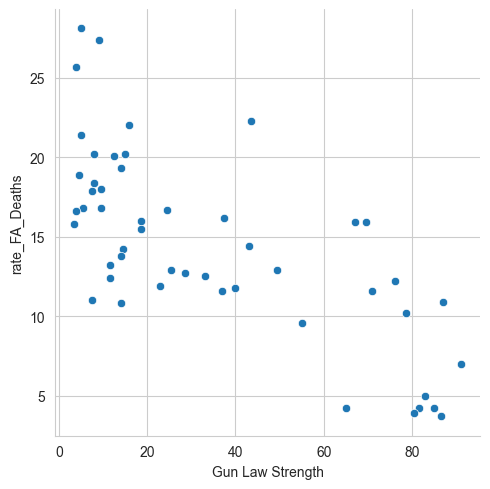

In [640]:
sns.relplot(df, x = 'Gun Law Strength', y = 'rate_FA_Deaths')

In [641]:
map = gpd.read_file('US_State_Boundaries/US_State_Boundaries.shp')

In [642]:
map_and_data = map.merge(df, right_on='State', left_on='NAME', how='right')

In [643]:
map_and_data

,FID,OBJECTID,NAME,STATE_ABBR,STATE_FIPS,ORDER_ADM,MONTH_ADM,DAY_ADM,YEAR_ADM,TYPE,...,Shape__Are,Shape__Len,geometry,State,Gun Law Strength,Scaled Gun Law Strength,name,rate_FA_Deaths,count_sup_FA_Deaths,Scaled FA Death
0,31,35,California,CA,06,31,September,9,1850,Land,...,41.613094,55.323399,"MULTIPOLYGON (((-117.10457 32.61287, -117.1059...",California,91.0,5,California,7.0,2735.0,7
1,5,5,Illinois,IL,17,21,December,3,1818,Land,...,15.408477,21.660211,"POLYGON ((-90.4371 42.50713, -90.42637 42.5070...",Illinois,87.0,5,Illinois,10.9,1364.0,10
2,36,40,Massachusetts,MA,25,6,February,6,1788,Land,...,2.292561,23.274490,"MULTIPOLYGON (((-70.80749 41.24899, -70.80973 ...",Massachusetts,86.5,5,Massachusetts,3.7,262.0,3
3,40,44,New York,NY,36,11,July,26,1788,Land,...,13.909031,42.221029,"MULTIPOLYGON (((-73.8339 40.59369, -73.83156 4...",New York,85.0,5,New York,4.2,830.0,4
4,32,36,Connecticut,CT,09,5,January,9,1788,Land,...,1.391289,7.986314,"MULTIPOLYGON (((-73.42085 41.04713, -73.42142 ...",Connecticut,83.0,5,Connecticut,5.0,180.0,5
5,47,53,Hawaii,HI,15,50,August,21,1959,Land,...,1.439866,14.685215,"MULTIPOLYGON (((-155.84982 20.268, -155.8476 2...",Hawaii,81.5,5,Hawaii,4.2,60.0,4
6,39,43,New Jersey,NJ,34,3,December,18,1787,Land,...,2.072956,17.481320,"MULTIPOLYGON (((-74.58208 39.28513, -74.58217 ...",New Jersey,80.5,5,New Jersey,3.9,360.0,3
7,37,41,Maryland,MD,24,7,April,28,1788,Land,...,2.664001,50.892779,"MULTIPOLYGON (((-76.08272 39.43786, -76.0837 3...",Maryland,78.5,4,Maryland,10.2,631.0,10
8,52,59,Washington,WA,53,42,November,11,1889,Land,...,20.843773,58.093615,"MULTIPOLYGON (((-123.34417 46.1662, -123.3425 ...",Washington,76.0,4,Washington,12.2,955.0,12
9,34,38,Delaware,DE,10,1,December,7,1787,Land,...,0.533126,5.468970,"MULTIPOLYGON (((-75.54026 39.49677, -75.54269 ...",Delaware,71.0,4,Delaware,11.6,120.0,11


def largest_polygon_safe(geom):
    """
    Return the largest polygon if MultiPolygon.
    Skip if geom is missing or not a polygon.
    """
    # Check if geometry is valid
    if geom is None or not hasattr(geom, 'geom_type'):
        return geom
    if geom.geom_type == "MultiPolygon":
        return max(geom.geoms, key=lambda g: g.area)
    elif geom.geom_type == "Polygon":
        return geom
    else:
        return geom

# Create a mask for Alaska
mask = map_and_data['State'] == 'Alaska'

# Apply function only to Alaska geometries
map_and_data.loc[mask, 'geometry'] = map_and_data.loc[mask, 'geometry'].apply(largest_polygon)

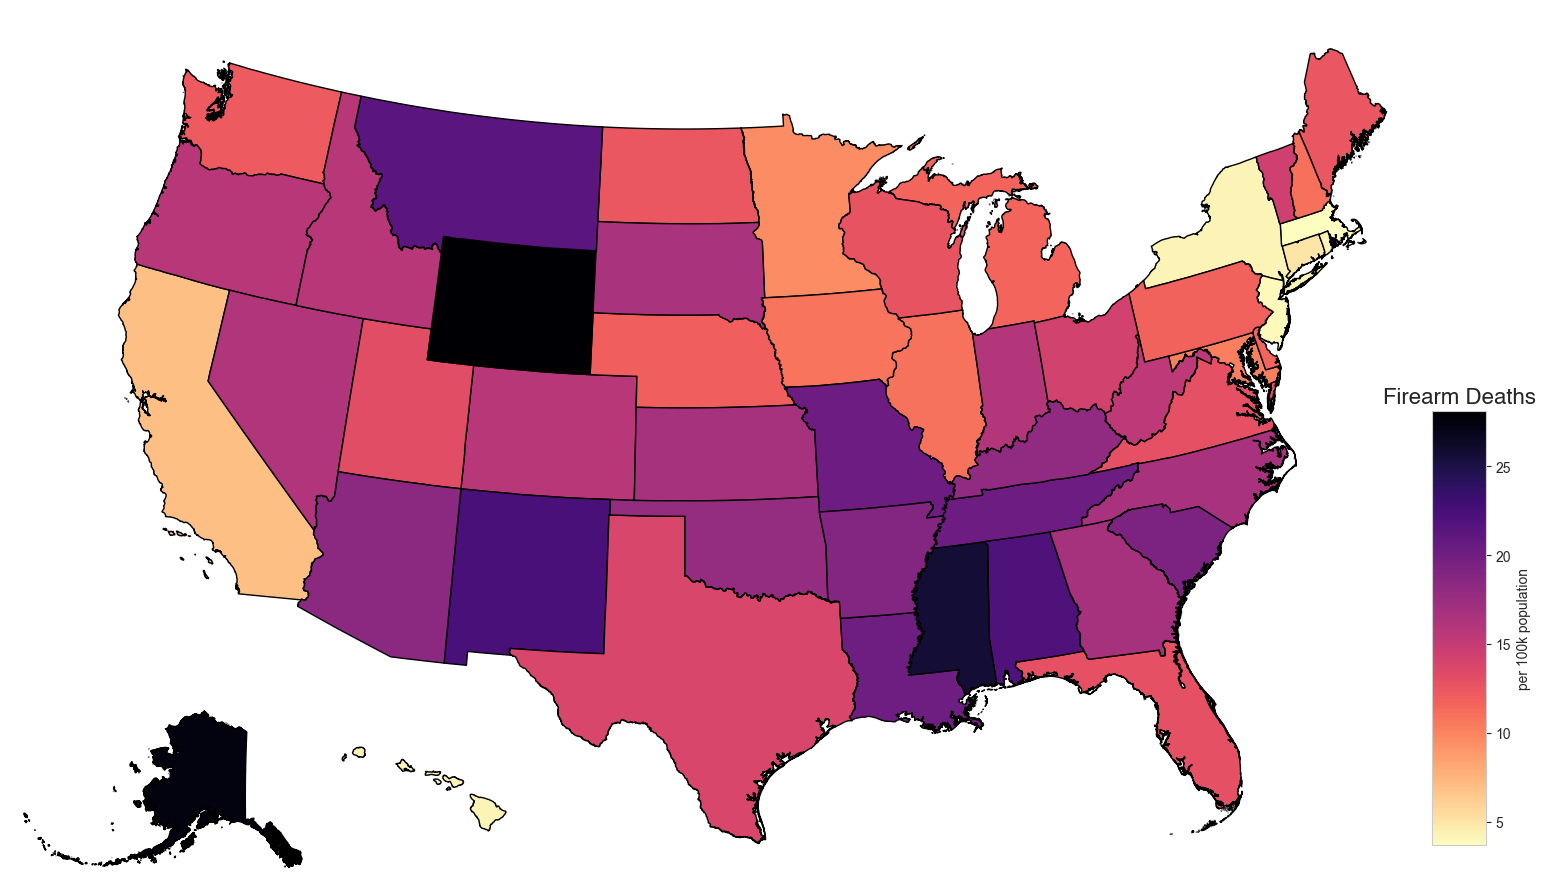

In [644]:
visframe = map_and_data.to_crs(epsg=2163)

vmin = visframe['rate_FA_Deaths'].min()
vmax = visframe['rate_FA_Deaths'].max()

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.colormaps['magma_r']

fig, ax = plt.subplots(1, figsize=(18,14))
ax.axis('off')

visframe[~visframe['NAME'].isin(['Hawaii','Alaska'])].plot(column = 'rate_FA_Deaths', cmap = cmap, norm = norm, edgecolor = 'black', linewidth = 1, ax = ax)

akax = fig.add_axes([0.1, 0.17, 0.17, 0.16])
akax.axis('off')
hiax = fig.add_axes([0.28, 0.20, 0.1, 0.1])
hiax.axis('off')

alaska_map = visframe[visframe['NAME'] == 'Alaska']
hawaii_map = visframe[visframe['NAME'] == 'Hawaii']

ak_centroid = alaska_map.geometry.centroid.union_all().centroid
alaska_map['geometry'] = alaska_map['geometry'].rotate(35, origin=(ak_centroid.x, ak_centroid.y))

hi_centroid = hawaii_map.geometry.centroid.union_all().centroid
hawaii_map['geometry'] = hawaii_map['geometry'].rotate(45, origin=(hi_centroid.x, hi_centroid.y))

alaska_map.plot(ax = akax, column = 'rate_FA_Deaths', cmap = cmap, norm = norm, edgecolor = 'black', linewidth = 1)
hawaii_map.plot(ax = hiax, column = 'rate_FA_Deaths', cmap = cmap, norm = norm, edgecolor = 'black', linewidth = 1)

cbax = fig.add_axes([0.89, 0.21, 0.03, 0.31])
cb = ColorbarBase(cbax, cmap = cmap, norm = norm, orientation = 'vertical', label = 'per 100k population')
cb_title = cbax.set_title('Firearm Deaths', font = 'Helvetica', fontsize = 16, fontweight = 'bold')

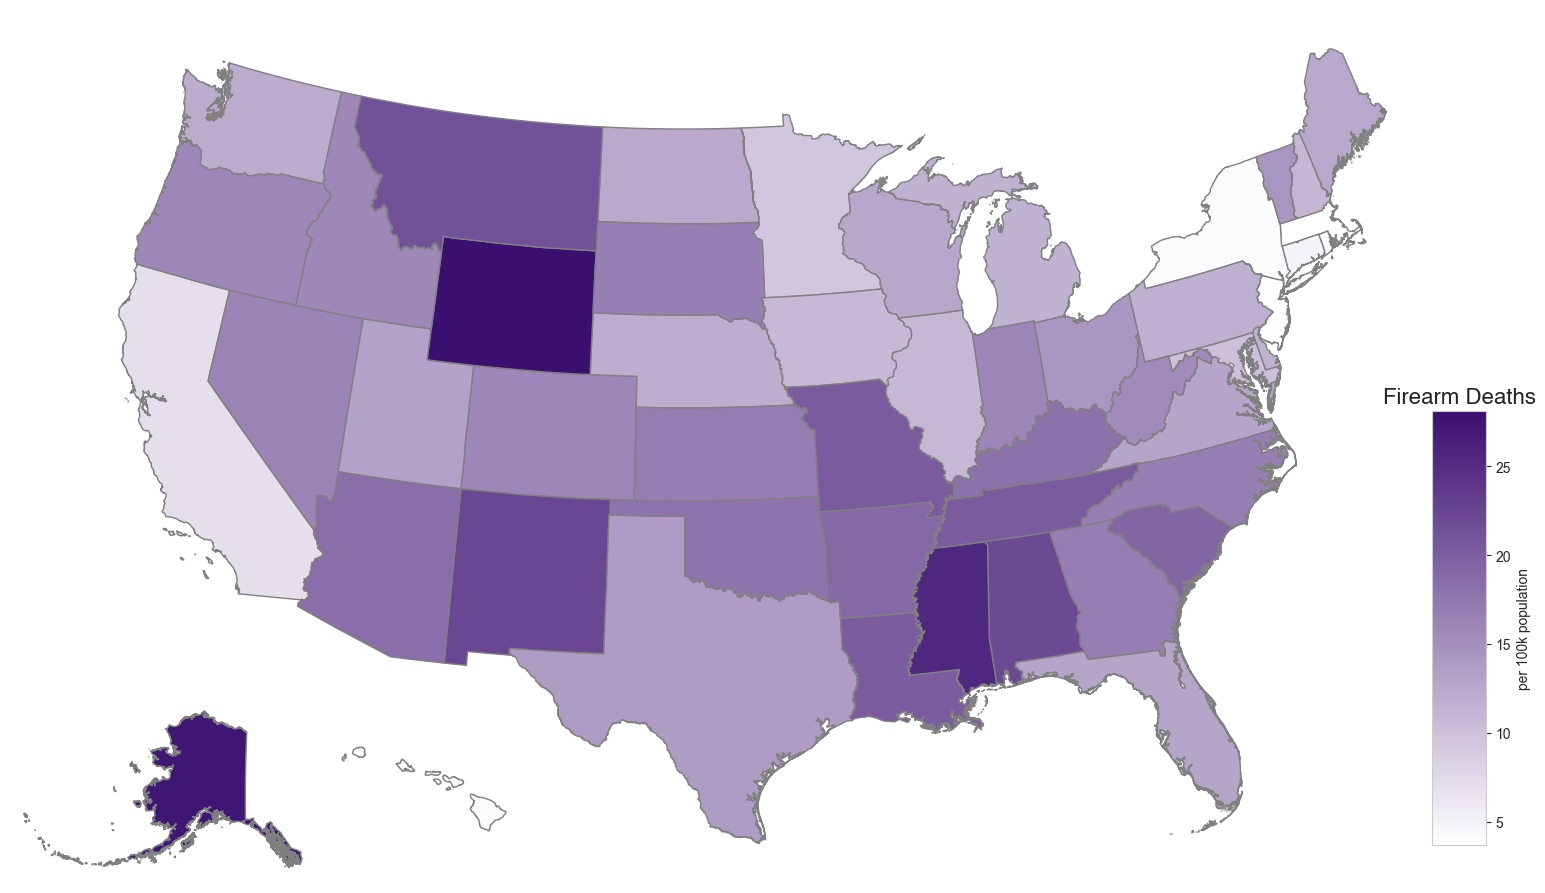

In [655]:

visframe = map_and_data.to_crs(epsg=2163)

vmin = visframe['rate_FA_Deaths'].min()
vmax = visframe['rate_FA_Deaths'].max()

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
colorrange = ['white', '#3b0f70']
custom_cmap = LinearSegmentedColormap.from_list('white_to_purple', colorrange)
cmap = custom_cmap

fig, ax = plt.subplots(1, figsize=(18,14))
ax.axis('off')

visframe[~visframe['NAME'].isin(['Hawaii','Alaska'])].plot(column = 'rate_FA_Deaths', cmap = cmap, norm = norm, edgecolor = 'gray', linewidth = 1, ax = ax)

akax = fig.add_axes([0.1, 0.17, 0.17, 0.16])
akax.axis('off')
hiax = fig.add_axes([0.28, 0.20, 0.1, 0.1])
hiax.axis('off')

alaska_map = visframe[visframe['NAME'] == 'Alaska']
hawaii_map = visframe[visframe['NAME'] == 'Hawaii']

ak_centroid = alaska_map.geometry.centroid.union_all().centroid
alaska_map['geometry'] = alaska_map['geometry'].rotate(35, origin=(ak_centroid.x, ak_centroid.y))

hi_centroid = hawaii_map.geometry.centroid.union_all().centroid
hawaii_map['geometry'] = hawaii_map['geometry'].rotate(45, origin=(hi_centroid.x, hi_centroid.y))

alaska_map.plot(ax = akax, column = 'rate_FA_Deaths', cmap = cmap, norm = norm, edgecolor = 'gray', linewidth = 1)
hawaii_map.plot(ax = hiax, column = 'rate_FA_Deaths', cmap = cmap, norm = norm, edgecolor = 'gray', linewidth = 1)

cbax = fig.add_axes([0.89, 0.21, 0.03, 0.31])
cb = ColorbarBase(cbax, cmap = cmap, norm = norm, orientation = 'vertical', label = 'per 100k population')
cb_title = cbax.set_title('Firearm Deaths', font = 'Helvetica', fontsize = 16, fontweight = 'bold')

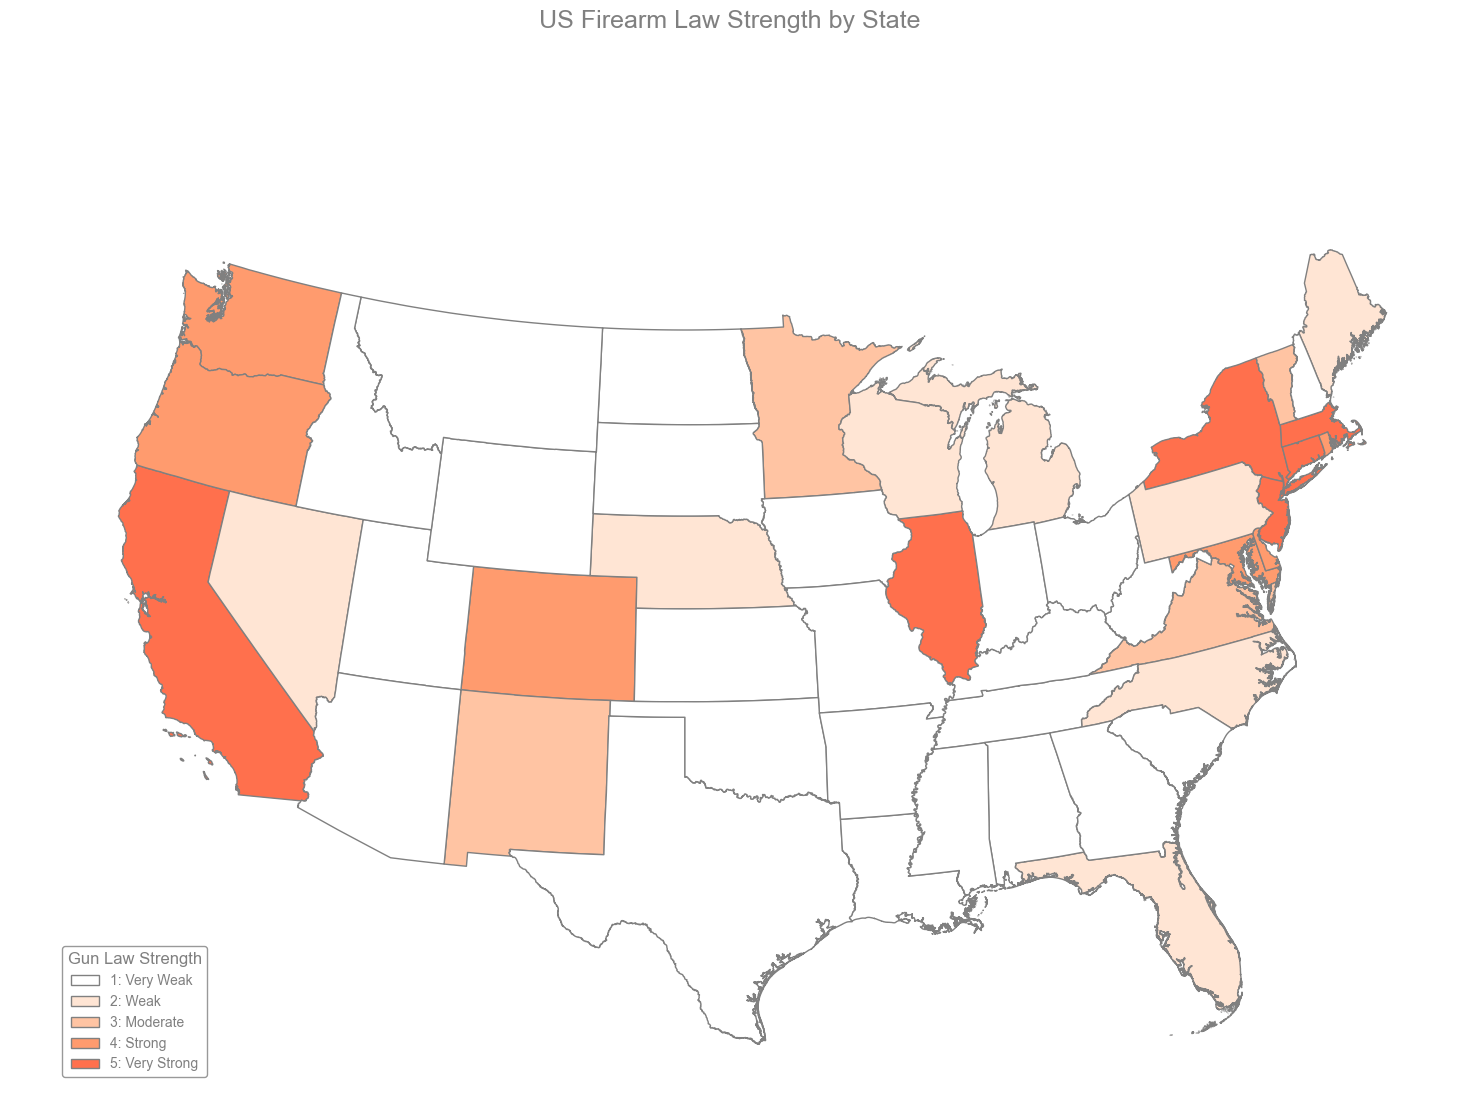

In [671]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Discrete colormap: white to muted orange
colors = ['#ffffff', '#ffe5d4', '#ffc4a3', '#ff9b6e', '#ff704d']  # light to deeper muted orange
cmap = ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=[0.5,1.5,2.5,3.5,4.5,5.5], ncolors=5)

fig, ax = plt.subplots(1, figsize=(18,14))
ax.axis('off')

# Main map (exclude AK & HI)
visframe[~visframe['NAME'].isin(['Hawaii','Alaska'])].plot(
    column='Scaled Gun Law Strength',
    cmap=cmap,
    norm=norm,
    edgecolor='gray',
    linewidth=1,
    ax=ax
)

# Alaska & Hawaii insets
akax = fig.add_axes([0.1, 0.17, 0.17, 0.16])
akax.axis('off')
hiax = fig.add_axes([0.28, 0.20, 0.1, 0.1])
hiax.axis('off')

alaska_map = visframe[visframe['NAME'] == 'Alaska'].copy()
hawaii_map = visframe[visframe['NAME'] == 'Hawaii'].copy()

# Rotate geometries for insets
alaska_map['geometry'] = alaska_map['geometry'].rotate(35, origin=alaska_map.geometry.centroid.iloc[0])
hawaii_map['geometry'] = hawaii_map['geometry'].rotate(45, origin=hawaii_map.geometry.centroid.iloc[0])

# Plot insets
# alaska_map.plot(ax=akax, column='Scaled Gun Law Strength', cmap=cmap, norm=norm, edgecolor='gray', linewidth=1)
# hawaii_map.plot(ax=hiax, column='Scaled Gun Law Strength', cmap=cmap, norm=norm, edgecolor='gray', linewidth=1)

# Legend box for discrete levels (all text gray)
legend_elements = [
    Patch(facecolor=colors[0], edgecolor='gray', label='1: Very Weak'),
    Patch(facecolor=colors[1], edgecolor='gray', label='2: Weak'),
    Patch(facecolor=colors[2], edgecolor='gray', label='3: Moderate'),
    Patch(facecolor=colors[3], edgecolor='gray', label='4: Strong'),
    Patch(facecolor=colors[4], edgecolor='gray', label='5: Very Strong'),
]
legend = ax.legend(
    handles=legend_elements,
    loc='lower left',
    title='Gun Law Strength',
    title_fontsize=12,
    fontsize=10,
    frameon=True,
    facecolor='white',
    edgecolor='gray'
)

# Set all legend text to gray
plt.setp(legend.get_title(), color='gray')
for text in legend.get_texts():
    text.set_color('gray')

# Optional: figure title
fig.suptitle(
    "US Firearm Law Strength by State",
    fontsize=18,
    color='gray',
    y=0.95
)

plt.show()

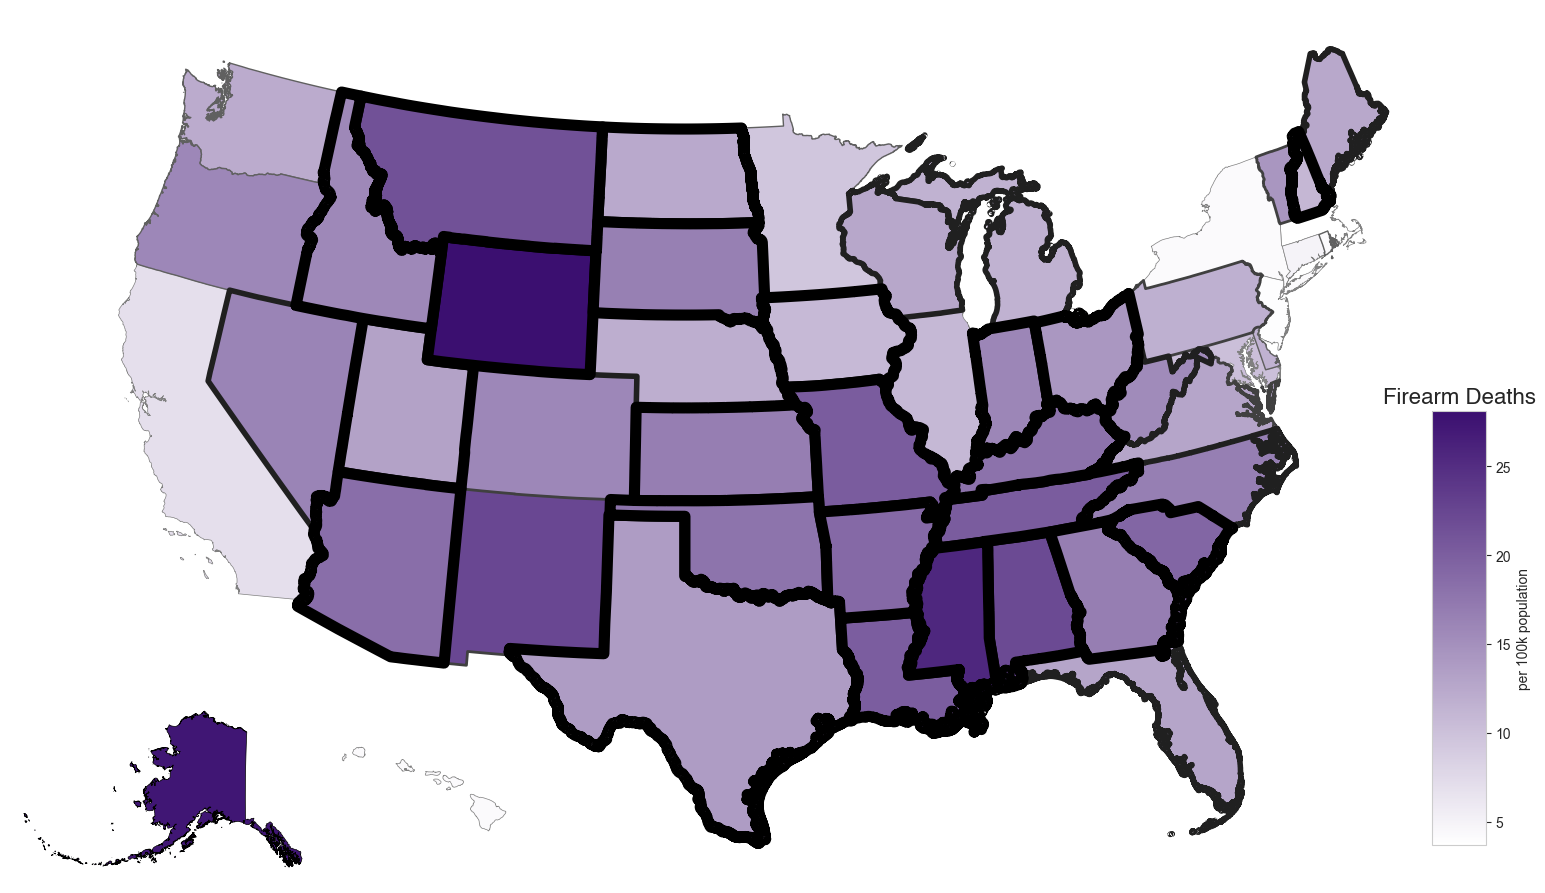

In [656]:

visframe = map_and_data.to_crs(epsg=2163)

vmin = visframe['rate_FA_Deaths'].min()
vmax = visframe['rate_FA_Deaths'].max()

# fill colors
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
colorrange = ['white', '#3b0f70']
custom_cmap = LinearSegmentedColormap.from_list('white_to_purple', colorrange)
cmap = custom_cmap

# edge colors
vmin_edge = visframe['Scaled Gun Law Strength'].min()
vmax_edge = visframe['Scaled Gun Law Strength'].max()
norm_edge = mcolors.Normalize(vmin=vmin_edge, vmax=vmax_edge)
colorrange_edge = ['black', 'gray']
custom_cmap_edge = LinearSegmentedColormap.from_list('yellow_to_white', colorrange_edge)
cmap_edge = custom_cmap_edge
edge_colors = cmap_edge(norm_edge(visframe['Scaled Gun Law Strength']))

# edge widths
linewidths = visframe['Scaled Gun Law Strength'].map({
    1: 8,
    2: 4,
    3: 2,
    4: 1,
    5: 0.5
})

fig, ax = plt.subplots(1, figsize=(18,14))
ax.axis('off')

visframe[~visframe['NAME'].isin(['Hawaii','Alaska'])].plot(column = 'rate_FA_Deaths', cmap = cmap, norm = norm, edgecolor = edge_colors, linewidth = linewidths, ax = ax)

akax = fig.add_axes([0.1, 0.17, 0.17, 0.16])
akax.axis('off')
hiax = fig.add_axes([0.28, 0.20, 0.1, 0.1])
hiax.axis('off')

alaska_map = visframe[visframe['NAME'] == 'Alaska']
hawaii_map = visframe[visframe['NAME'] == 'Hawaii']

ak_centroid = alaska_map.geometry.centroid.union_all().centroid
alaska_map['geometry'] = alaska_map['geometry'].rotate(35, origin=(ak_centroid.x, ak_centroid.y))

hi_centroid = hawaii_map.geometry.centroid.union_all().centroid
hawaii_map['geometry'] = hawaii_map['geometry'].rotate(45, origin=(hi_centroid.x, hi_centroid.y))

alaska_edge = cmap_edge(norm_edge(alaska_map['Scaled Gun Law Strength']))
hawaii_edge = cmap_edge(norm_edge(hawaii_map['Scaled Gun Law Strength']))

alaska_map.plot(ax = akax, column = 'rate_FA_Deaths', cmap = cmap, norm = norm, edgecolor = alaska_edge, linewidth = linewidths)
hawaii_map.plot(ax = hiax, column = 'rate_FA_Deaths', cmap = cmap, norm = norm, edgecolor = hawaii_edge, linewidth = linewidths)

cbax = fig.add_axes([0.89, 0.21, 0.03, 0.31])
cb = ColorbarBase(cbax, cmap = cmap, norm = norm, orientation = 'vertical', label = 'per 100k population')
cb_title = cbax.set_title('Firearm Deaths', font = 'Helvetica', fontsize = 16, fontweight = 'bold')

(np.float64(-2259282.3557511237),
 np.float64(2743816.50357248),
 np.float64(-2259480.5383623587),
 np.float64(874853.5496290799))

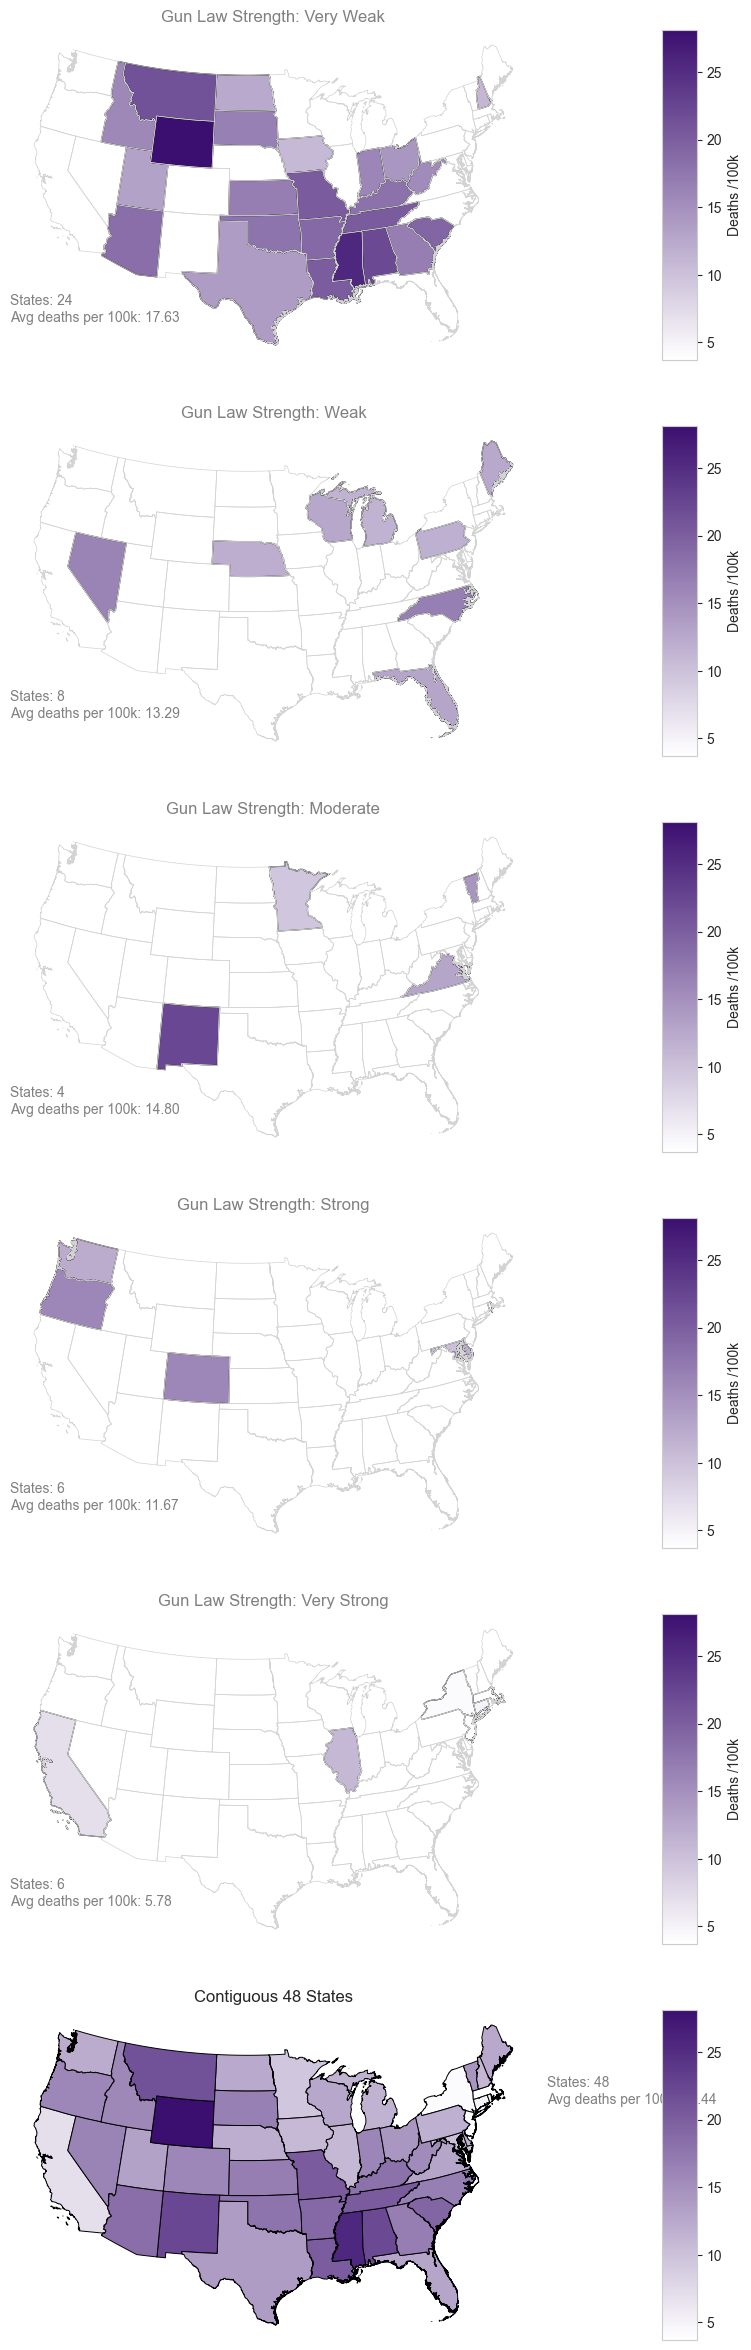

In [657]:
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec

visframe = visframe[~visframe['NAME'].isin(['Alaska','Hawaii'])]

levels = sorted(visframe['Scaled Gun Law Strength'].unique())

labels = {
    1: "Very Weak",
    2: "Weak",
    3: "Moderate",
    4: "Strong",
    5: "Very Strong"
}

fig = plt.figure(figsize=(10,30))

gs = gridspec.GridSpec(6, 2, width_ratios=[20,1], wspace=0.1)

axes = []
caxes = []

for i in range(6):
    axes.append(fig.add_subplot(gs[i,0]))
    caxes.append(fig.add_subplot(gs[i,1]))

for i, level in enumerate(levels):

    ax = axes[i]
    cax = caxes[i]

    # background outline
    visframe.boundary.plot(ax=ax, color='lightgray', linewidth=0.5)

    subset = visframe[visframe['Scaled Gun Law Strength'] == level]

    subset.plot(
        column='rate_FA_Deaths',
        cmap=cmap,
        norm=norm,
        edgecolor='black',
        linewidth=0.7,
        legend=True,
        cax=cax,
        ax=ax
    )

    n_states = len(subset)
    avg_deaths = subset['rate_FA_Deaths'].mean()

    ax.set_title(f"Gun Law Strength: {labels[level]}", color = 'gray')

    ax.text(
        0.0, 0.2,
        f"States: {n_states}\nAvg deaths per 100k: {avg_deaths:.2f}",
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        color = 'gray',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

    ax.axis('off')

    cax.set_ylabel("Deaths /100k")


# final panel with all states
ax = axes[-1]
cax = caxes[-1]

visframe.plot(
    column='rate_FA_Deaths',
    cmap=cmap,
    norm=norm,
    edgecolor='black',
    linewidth=0.7,
    legend=True,
    cax=cax,
    ax=ax
)

n_states = len(visframe)
avg_deaths = visframe['rate_FA_Deaths'].mean()

ax.set_title("Contiguous 48 States")

ax.text(
    1.02, 0.8,
    f"States: {n_states}\nAvg deaths per 100k: {avg_deaths:.2f}",
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=10,
    color = 'gray',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
)

ax.axis('off')

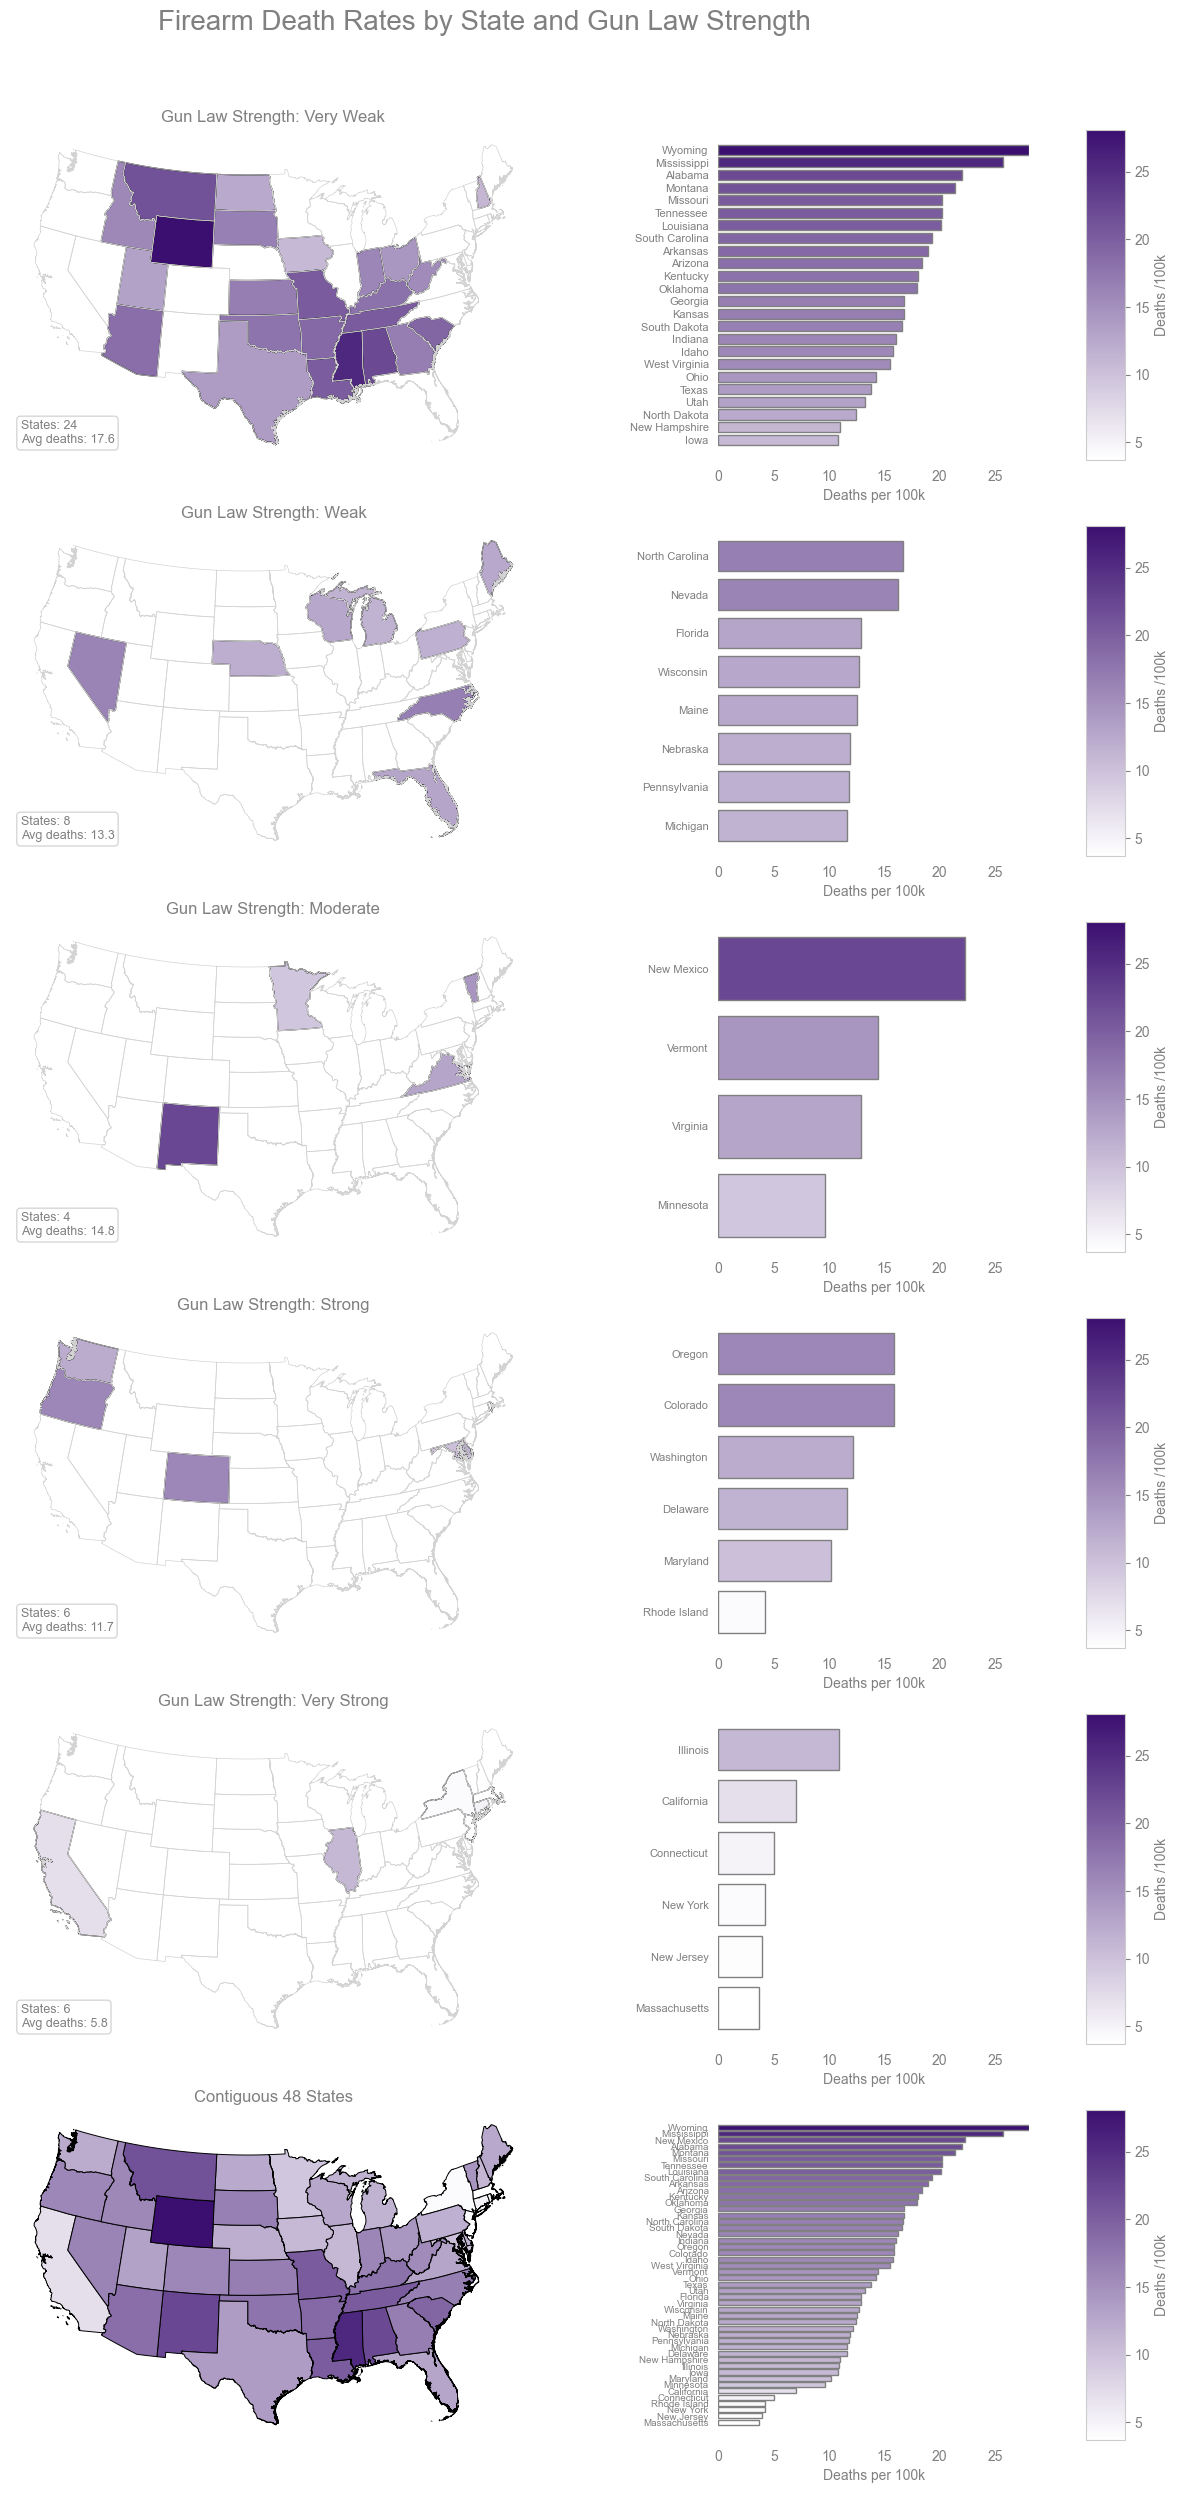

In [659]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import string

# Remove Alaska & Hawaii
visframe = visframe[~visframe['NAME'].isin(['Alaska','Hawaii'])]

levels = sorted(visframe['Scaled Gun Law Strength'].unique())

labels = {
    1: "Very Weak",
    2: "Weak",
    3: "Moderate",
    4: "Strong",
    5: "Very Strong"
}

fig = plt.figure(figsize=(16,30))

# 3 columns: map | bar chart | colorbar
gs = gridspec.GridSpec(6, 3, width_ratios=[20,8,1], wspace=0.15)

map_axes = []
bar_axes = []
caxes = []

for i in range(6):
    map_axes.append(fig.add_subplot(gs[i,0]))
    bar_axes.append(fig.add_subplot(gs[i,1]))
    caxes.append(fig.add_subplot(gs[i,2]))

bar_max = visframe['rate_FA_Deaths'].max()

for i, level in enumerate(levels):
    ax = map_axes[i]
    bar_ax = bar_axes[i]
    cax = caxes[i]

    visframe.boundary.plot(ax=ax, color='lightgray', linewidth=0.5)

    subset = visframe[visframe['Scaled Gun Law Strength'] == level]

    # Choropleth map with individual colorbar
    subset.plot(
        column='rate_FA_Deaths',
        cmap=cmap,
        norm=norm,
        edgecolor='black',
        linewidth=0.7,
        legend=True,
        cax=cax,
        ax=ax
    )

    # Panel title
    ax.set_title(f"Gun Law Strength: {labels[level]}", color='gray')

    # Summary box
    n_states = subset['NAME'].nunique()
    avg_deaths = subset['rate_FA_Deaths'].mean()
    ax.text(
        0.02, 0.05,
        f"States: {n_states}\nAvg deaths: {avg_deaths:.1f}",
        transform=ax.transAxes,
        fontsize=9,
        color='gray',
        bbox=dict(
            facecolor='white',
            edgecolor='lightgray',
            boxstyle='round,pad=0.3',
            alpha=0.9
        )
    )

    ax.axis('off')

    # Horizontal bar chart
    subset_sorted = subset.sort_values('rate_FA_Deaths')
    bar_ax.barh(
        subset_sorted['NAME'],
        subset_sorted['rate_FA_Deaths'],
        color=cmap(norm(subset_sorted['rate_FA_Deaths'])),
        edgecolor='gray',
    )
    bar_ax.grid(False)
    bar_ax.set_xlim(0, bar_max)
    bar_ax.set_xlabel("Deaths per 100k", color='gray')
    bar_ax.set_ylabel("")
    bar_ax.tick_params(axis='y', labelsize=8, colors='gray')
    bar_ax.tick_params(axis='x', colors='gray')
    bar_ax.spines[['top','right', 'bottom', 'left']].set_visible(False)

    # Colorbar labels
    cax.set_ylabel("Deaths /100k", color='gray')
    cax.tick_params(colors='gray')

# Final panel: all contiguous states
ax = map_axes[-1]
bar_ax = bar_axes[-1]
cax = caxes[-1]

visframe.plot(
    column='rate_FA_Deaths',
    cmap=cmap,
    norm=norm,
    edgecolor='black',
    linewidth=0.7,
    legend=True,
    cax=cax,
    ax=ax
)

subset_sorted = visframe.sort_values('rate_FA_Deaths')
bar_ax.barh(
    subset_sorted['NAME'],
    subset_sorted['rate_FA_Deaths'],
    color=cmap(norm(subset_sorted['rate_FA_Deaths'])),
    edgecolor='gray'
)
bar_ax.grid(False)
bar_ax.set_xlim(0, bar_max)
bar_ax.tick_params(axis='y', labelsize=7, colors='gray')
bar_ax.tick_params(axis='x', colors='gray')
bar_ax.spines[['top','right', 'bottom', 'left']].set_visible(False)
bar_ax.set_xlabel("Deaths per 100k", color='gray')

ax.set_title("Contiguous 48 States", color='gray')
ax.axis('off')
cax.set_ylabel("Deaths /100k", color='gray')
cax.tick_params(colors='gray')
fig.suptitle(
    "Firearm Death Rates by State and Gun Law Strength",
    fontsize=20,
    y=0.92,
    color='gray'
)

plt.show()


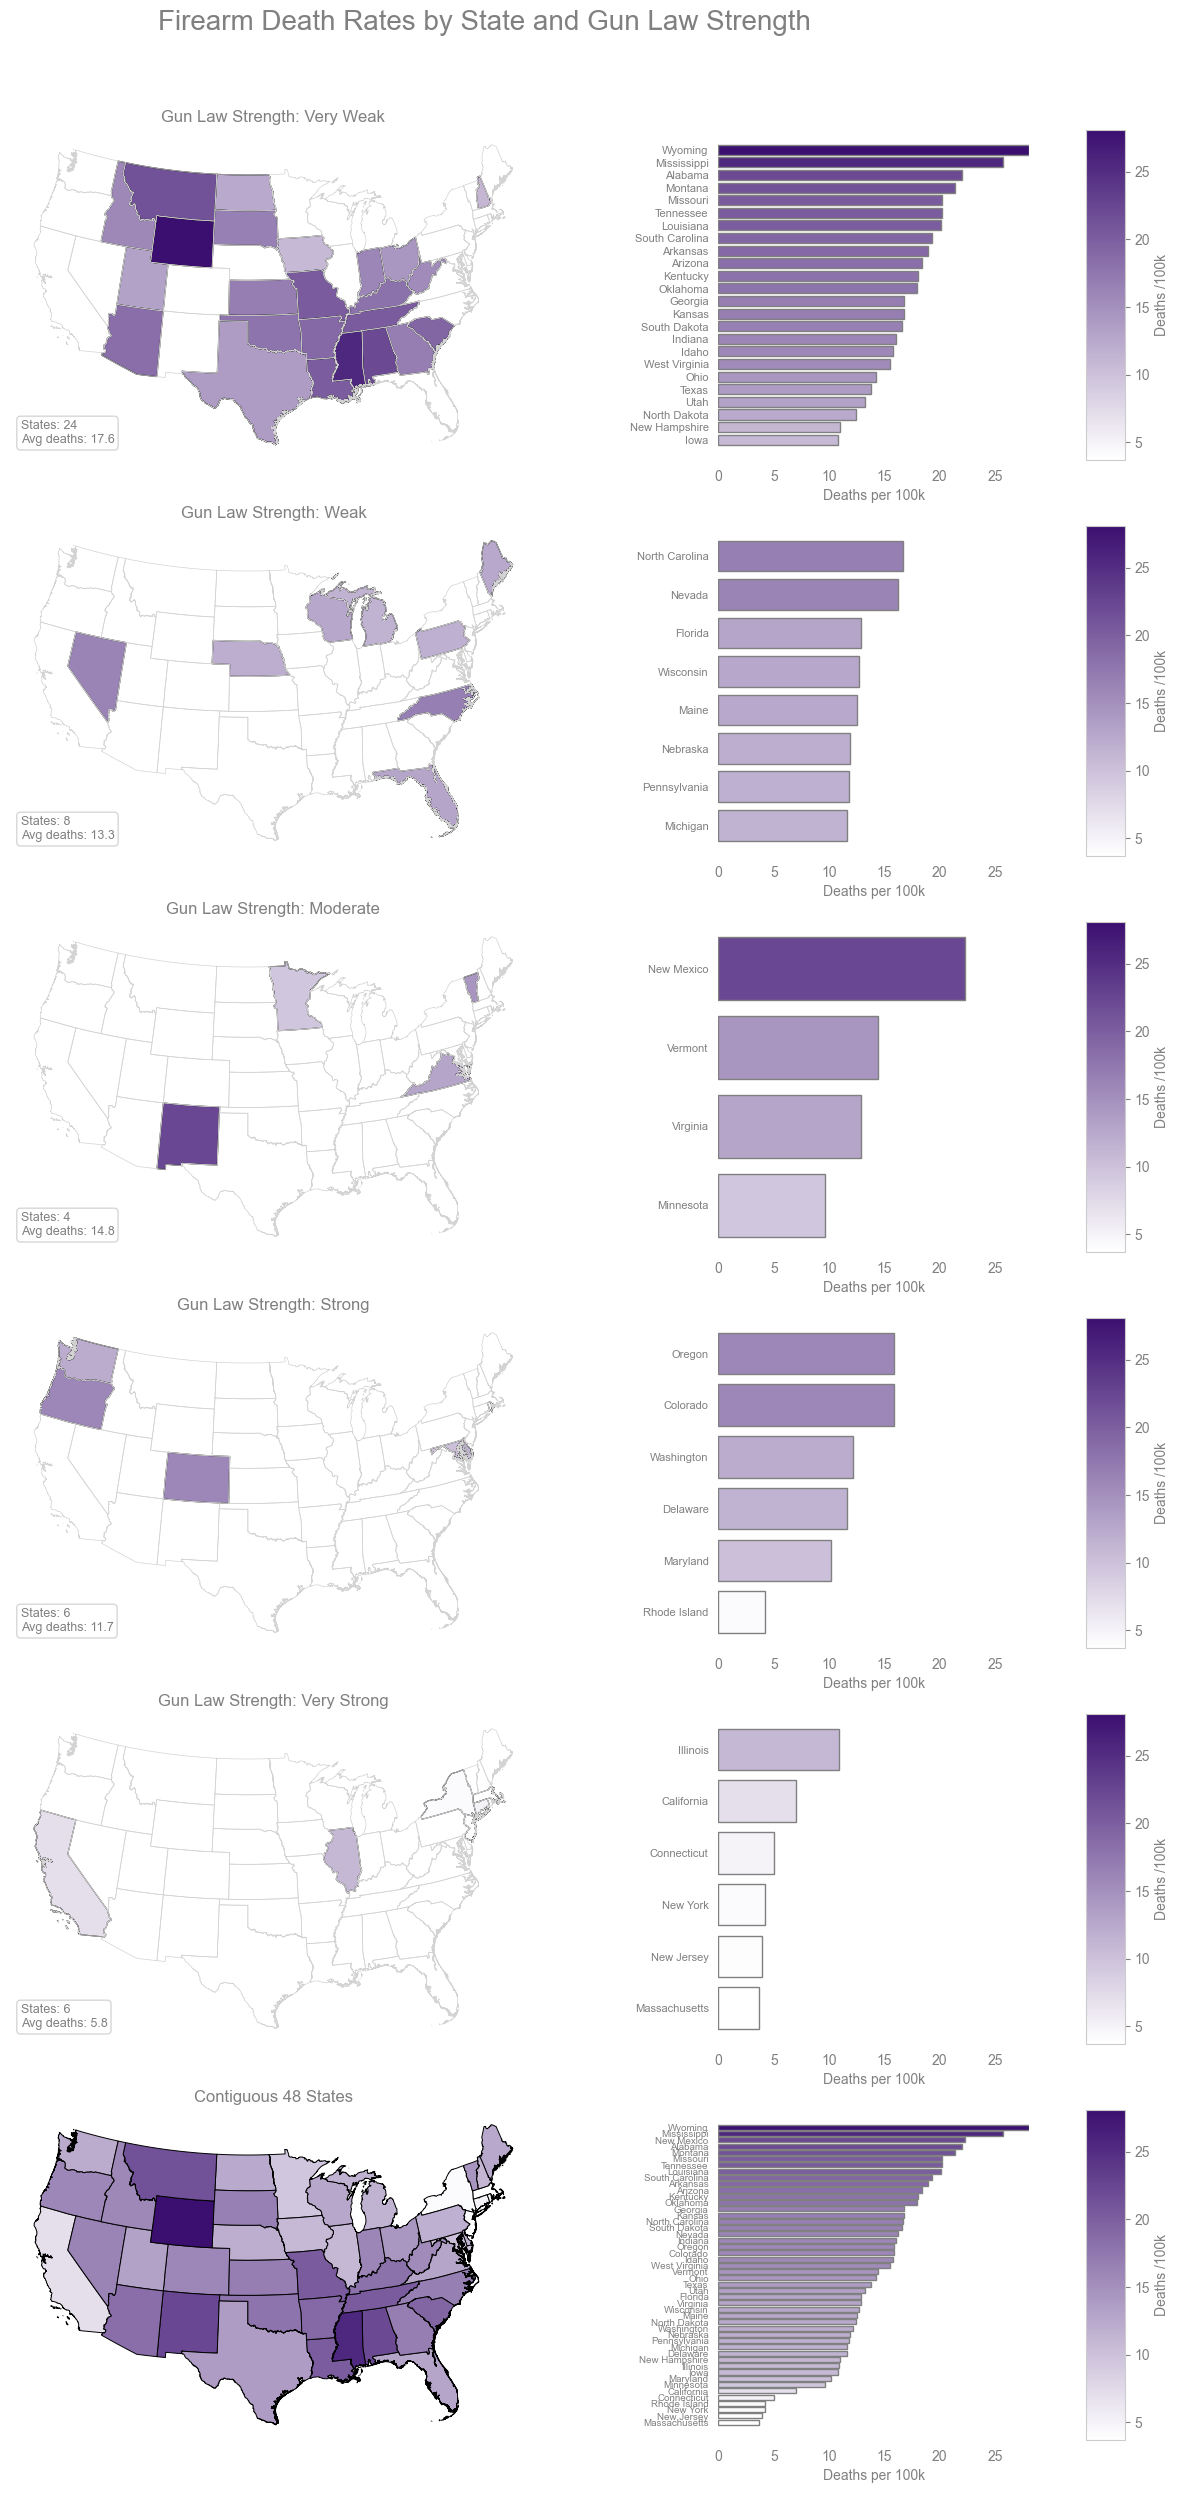

In [662]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import string

# Remove Alaska & Hawaii
visframe = visframe[~visframe['NAME'].isin(['Alaska','Hawaii'])]

levels = sorted(visframe['Scaled Gun Law Strength'].unique())

labels = {
    1: "Very Weak",
    2: "Weak",
    3: "Moderate",
    4: "Strong",
    5: "Very Strong"
}

fig = plt.figure(figsize=(16,30))

# 3 columns: map | bar chart | colorbar
gs = gridspec.GridSpec(6, 3, width_ratios=[20,8,1], wspace=0.15)

map_axes = []
bar_axes = []
caxes = []

for i in range(6):
    map_axes.append(fig.add_subplot(gs[i,0]))
    bar_axes.append(fig.add_subplot(gs[i,1]))
    caxes.append(fig.add_subplot(gs[i,2]))

bar_max = visframe['rate_FA_Deaths'].max()

for i, level in enumerate(levels):
    ax = map_axes[i]
    bar_ax = bar_axes[i]
    cax = caxes[i]

    visframe.boundary.plot(ax=ax, color='lightgray', linewidth=0.5)

    subset = visframe[visframe['Scaled Gun Law Strength'] == level]

    # Choropleth map with individual colorbar
    subset.plot(
        column='rate_FA_Deaths',
        cmap=cmap,
        norm=norm,
        edgecolor='black',
        linewidth=0.7,
        legend=True,
        cax=cax,
        ax=ax
    )

    # Panel title
    ax.set_title(f"Gun Law Strength: {labels[level]}", color='gray')

    # Summary box
    n_states = subset['NAME'].nunique()
    avg_deaths = subset['rate_FA_Deaths'].mean()
    ax.text(
        0.02, 0.05,
        f"States: {n_states}\nAvg deaths: {avg_deaths:.1f}",
        transform=ax.transAxes,
        fontsize=9,
        color='gray',
        bbox=dict(
            facecolor='white',
            edgecolor='lightgray',
            boxstyle='round,pad=0.3',
            alpha=0.9
        )
    )

    ax.axis('off')

    # Horizontal bar chart
    subset_sorted = subset.sort_values('rate_FA_Deaths')
    bar_ax.barh(
        subset_sorted['NAME'],
        subset_sorted['rate_FA_Deaths'],
        color=cmap(norm(subset_sorted['rate_FA_Deaths'])),
        edgecolor='gray',
    )
    bar_ax.grid(False)
    bar_ax.set_xlim(0, bar_max)
    bar_ax.set_xlabel("Deaths per 100k", color='gray')
    bar_ax.set_ylabel("")
    bar_ax.tick_params(axis='y', labelsize=8, colors='gray')
    bar_ax.tick_params(axis='x', colors='gray')
    bar_ax.spines[['top','right', 'bottom', 'left']].set_visible(False)

    # Colorbar labels
    cax.set_ylabel("Deaths /100k", color='gray')
    cax.tick_params(colors='gray')

# Final panel: all contiguous states
ax = map_axes[-1]
bar_ax = bar_axes[-1]
cax = caxes[-1]

visframe.plot(
    column='rate_FA_Deaths',
    cmap=cmap,
    norm=norm,
    edgecolor='black',
    linewidth=0.7,
    legend=True,
    cax=cax,
    ax=ax
)

subset_sorted = visframe.sort_values('rate_FA_Deaths')
bar_ax.barh(
    subset_sorted['NAME'],
    subset_sorted['rate_FA_Deaths'],
    color=cmap(norm(subset_sorted['rate_FA_Deaths'])),
    edgecolor='gray'
)
bar_ax.grid(False)
bar_ax.set_xlim(0, bar_max)
bar_ax.tick_params(axis='y', labelsize=7, colors='gray')
bar_ax.tick_params(axis='x', colors='gray')
bar_ax.spines[['top','right', 'bottom', 'left']].set_visible(False)
bar_ax.set_xlabel("Deaths per 100k", color='gray')

ax.set_title("Contiguous 48 States", color='gray')
ax.axis('off')
cax.set_ylabel("Deaths /100k", color='gray')
cax.tick_params(colors='gray')
fig.suptitle(
    "Firearm Death Rates by State and Gun Law Strength",
    fontsize=20,
    y=0.92,
    color='gray'
)
plt.savefig("multi_map.png", dpi=300, bbox_inches='tight')
plt.show()


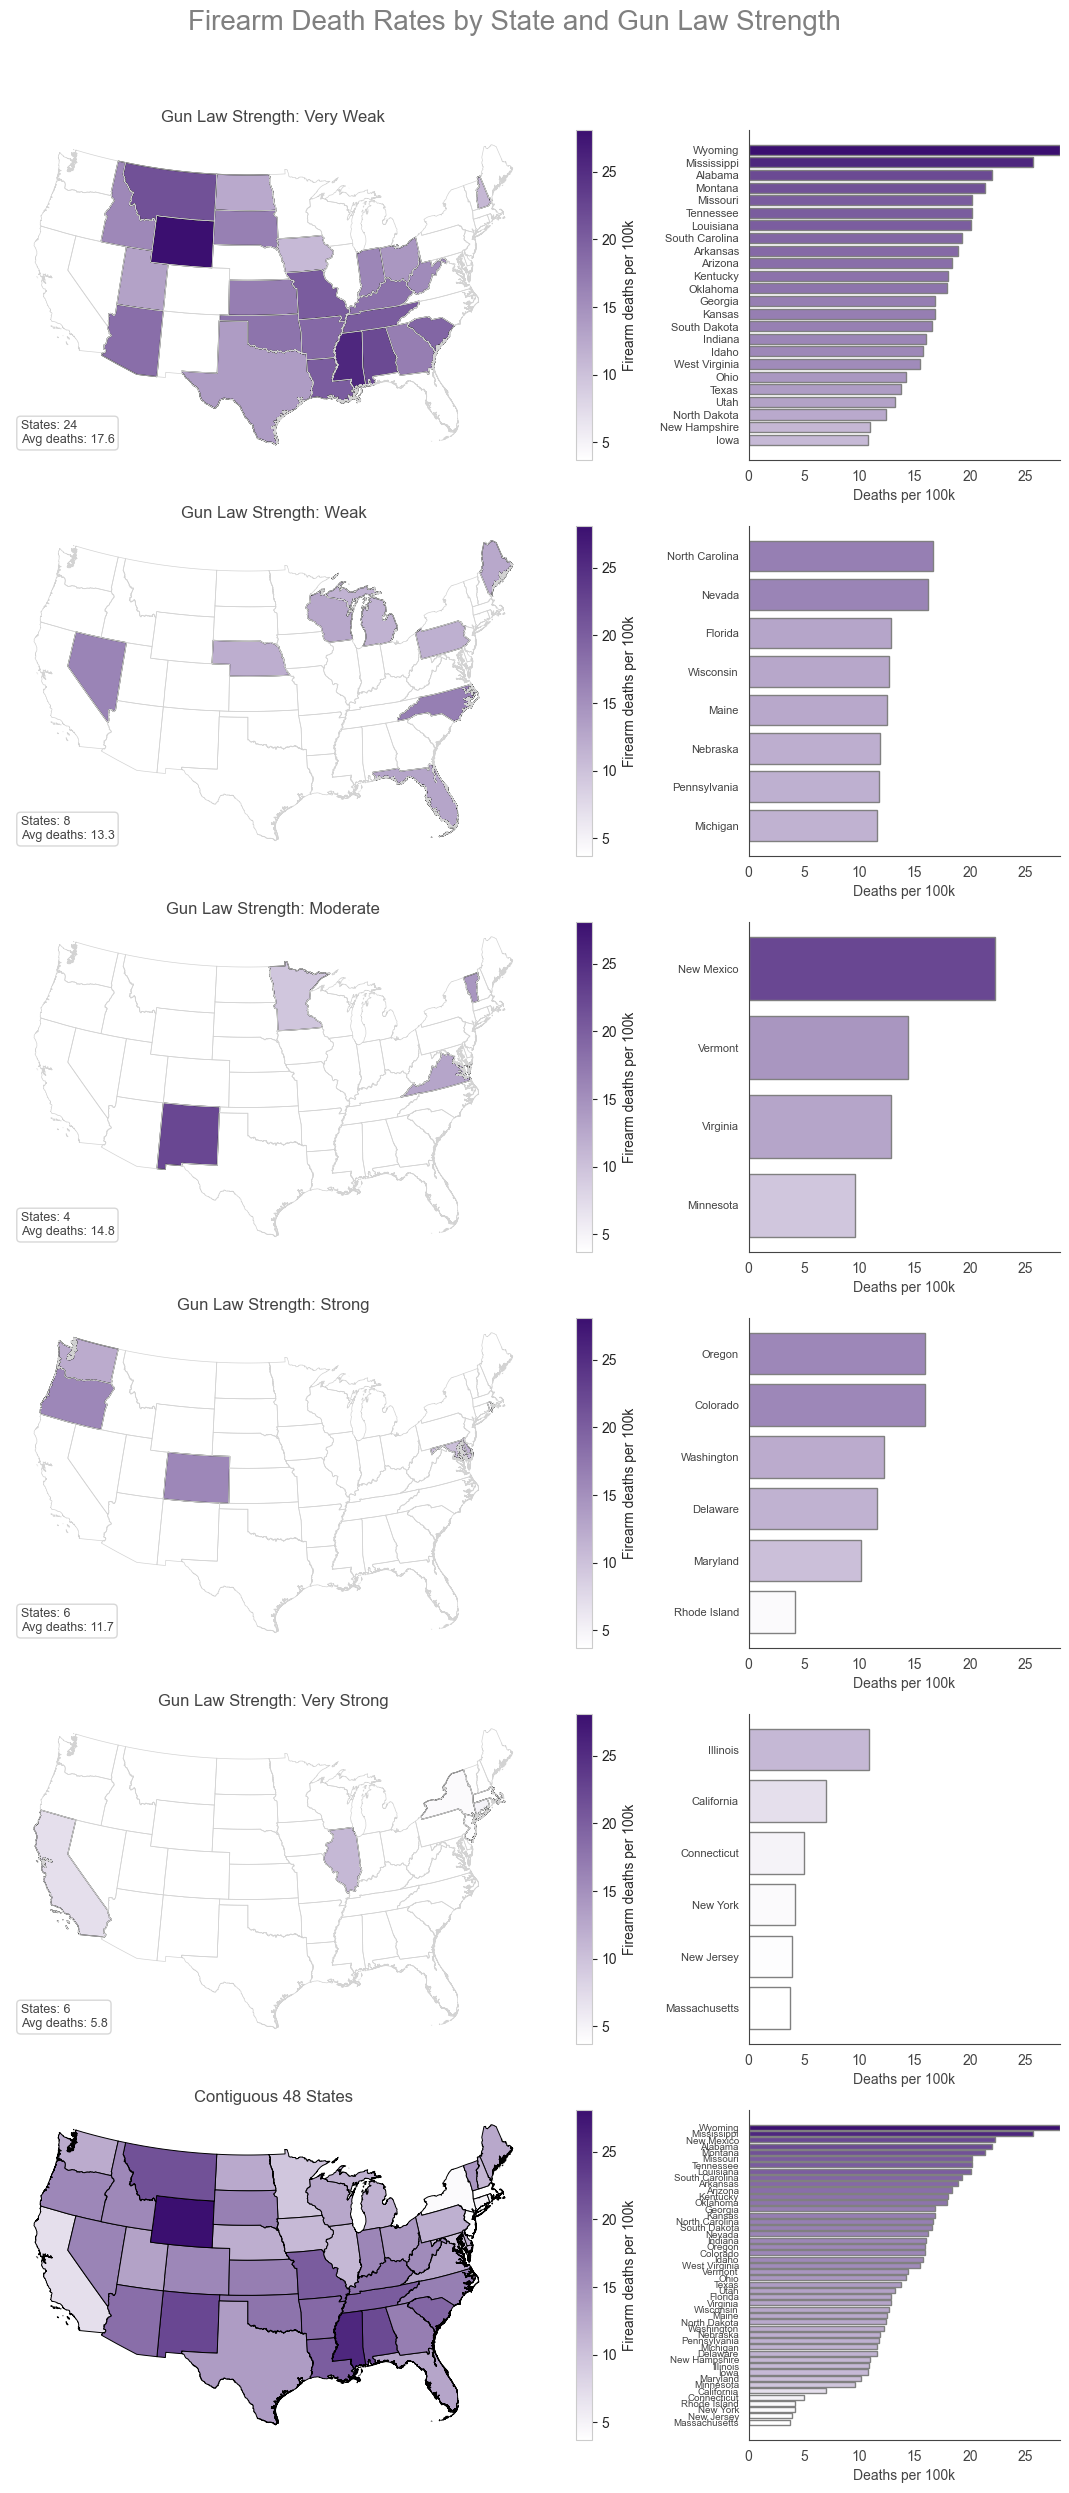

In [649]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import string

# Remove Alaska & Hawaii
visframe = visframe[~visframe['NAME'].isin(['Alaska','Hawaii'])]

levels = sorted(visframe['Scaled Gun Law Strength'].unique())

labels = {
    1: "Very Weak",
    2: "Weak",
    3: "Moderate",
    4: "Strong",
    5: "Very Strong"
}

fig = plt.figure(figsize=(16,30))

# 3 columns: map | bar chart | colorbar
gs = gridspec.GridSpec(6, 3, width_ratios=[20,8,1], wspace=0.15)

map_axes = []
bar_axes = []

for i in range(6):
    map_axes.append(fig.add_subplot(gs[i,0]))
    bar_axes.append(fig.add_subplot(gs[i,1]))

bar_max = visframe['rate_FA_Deaths'].max()

for i, level in enumerate(levels):
    ax = map_axes[i]
    bar_ax = bar_axes[i]

    visframe.boundary.plot(ax=ax, color='lightgray', linewidth=0.5)

    subset = visframe[visframe['Scaled Gun Law Strength'] == level]

    # Choropleth map with individual colorbar
    subset.plot(
        column='rate_FA_Deaths',
        cmap=cmap,
        norm=norm,
        edgecolor='black',
        linewidth=0.7,
        legend=True,
        ax=ax,
        legend_kwds={'label':'Firearm deaths per 100k', 'orientation':'vertical'}
    )

    # Panel title
    ax.set_title(f"Gun Law Strength: {labels[level]}", color='#444444')

    # Summary box
    n_states = subset['NAME'].nunique()
    avg_deaths = subset['rate_FA_Deaths'].mean()
    ax.text(
        0.02, 0.05,
        f"States: {n_states}\nAvg deaths: {avg_deaths:.1f}",
        transform=ax.transAxes,
        fontsize=9,
        color='#444444',
        bbox=dict(
            facecolor='white',
            edgecolor='lightgray',
            boxstyle='round,pad=0.3',
            alpha=0.9
        )
    )

    ax.axis('off')

    # Horizontal bar chart
    subset_sorted = subset.sort_values('rate_FA_Deaths')
    bar_ax.barh(
        subset_sorted['NAME'],
        subset_sorted['rate_FA_Deaths'],
        color=cmap(norm(subset_sorted['rate_FA_Deaths'])),
        edgecolor='gray',
    )
    bar_ax.grid(False)
    bar_ax.set_xlim(0, bar_max)
    bar_ax.set_xlabel("Deaths per 100k", color='#444444')
    bar_ax.set_ylabel("")
    bar_ax.tick_params(axis='y', labelsize=8, colors='#444444')
    bar_ax.tick_params(axis='x', colors='#444444')
    bar_ax.spines[['top','right']].set_visible(False)
    bar_ax.spines[['bottom','left']].set_color('#444444')


# Final panel: all contiguous states
ax = map_axes[-1]
bar_ax = bar_axes[-1]

visframe.plot(
    column='rate_FA_Deaths',
    cmap=cmap,
    norm=norm,
    edgecolor='black',
    linewidth=0.7,
    legend=True,
    ax=ax,
    legend_kwds={'label':'Firearm deaths per 100k', 'orientation':'vertical'}
)

subset_sorted = visframe.sort_values('rate_FA_Deaths')
bar_ax.barh(
    subset_sorted['NAME'],
    subset_sorted['rate_FA_Deaths'],
    color=cmap(norm(subset_sorted['rate_FA_Deaths'])),
    edgecolor = 'gray'
)
bar_ax.grid(False)
bar_ax.set_xlim(0, bar_max)
bar_ax.tick_params(axis='y', labelsize=7, colors='#444444')
bar_ax.tick_params(axis='x', colors='#444444')
bar_ax.spines[['top','right']].set_visible(False)
bar_ax.spines[['bottom','left']].set_color('#444444')
bar_ax.set_xlabel("Deaths per 100k", color='#444444')
ax.set_title("Contiguous 48 States", color='#444444')
ax.axis('off')

fig.suptitle(
    "Firearm Death Rates by State and Gun Law Strength",
    fontsize=20,
    y=0.92,
    color='gray'
)

plt.show()

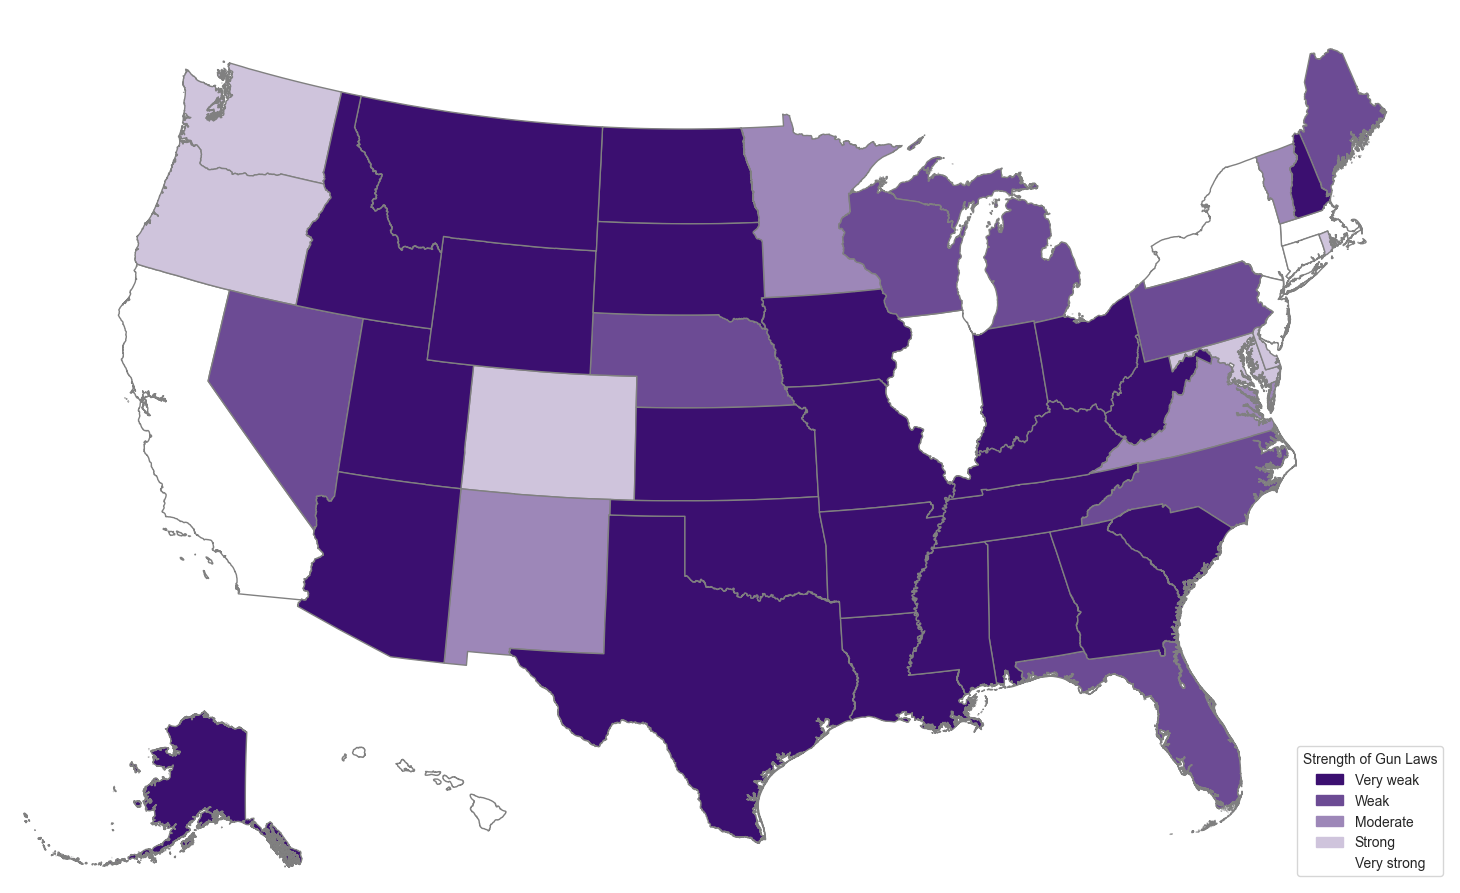

In [650]:
visframe = map_and_data.to_crs(epsg=2163)

vmin = visframe['Scaled Gun Law Strength'].min()
vmax = visframe['Scaled Gun Law Strength'].max()

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
colorrange = ['#3b0f70', 'white']
custom_cmap = LinearSegmentedColormap.from_list('purple_to_white', colorrange)
cmap = custom_cmap

fig, ax = plt.subplots(1, figsize=(18,14))
ax.axis('off')

visframe[~visframe['NAME'].isin(['Hawaii','Alaska'])].plot(column = 'Scaled Gun Law Strength', cmap = cmap, norm = norm, edgecolor = 'gray', linewidth = 1, ax = ax)

akax = fig.add_axes([0.1, 0.17, 0.17, 0.16])
akax.axis('off')
hiax = fig.add_axes([0.28, 0.20, 0.1, 0.1])
hiax.axis('off')

alaska_map = visframe[visframe['NAME'] == 'Alaska']
hawaii_map = visframe[visframe['NAME'] == 'Hawaii']

ak_centroid = alaska_map.geometry.centroid.union_all().centroid
alaska_map['geometry'] = alaska_map['geometry'].rotate(35, origin=(ak_centroid.x, ak_centroid.y))

hi_centroid = hawaii_map.geometry.centroid.union_all().centroid
hawaii_map['geometry'] = hawaii_map['geometry'].rotate(45, origin=(hi_centroid.x, hi_centroid.y))

alaska_map.plot(ax = akax, column = 'Scaled Gun Law Strength', cmap = cmap, norm = norm, edgecolor = 'gray', linewidth = 1)
hawaii_map.plot(ax = hiax, column = 'Scaled Gun Law Strength', cmap = cmap, norm = norm, edgecolor = 'gray', linewidth = 1)

scale_values = ['Very weak', 'Weak', 'Moderate', 'Strong', 'Very strong']

colors_map = custom_cmap(np.linspace(0,1,5))
value_to_color = dict(zip(scale_values, colors_map))
patches = [mpatches.Patch(color=color, label=f'{val}') for val, color in value_to_color.items()]
legend = ax.legend(handles=patches, title = 'Strength of Gun Laws', loc = 'lower right')

In [651]:
pearson_corr = df['Gun Law Strength'].corr(df['rate_FA_Deaths'])
print("Pearson correlation:", pearson_corr)

spearman_corr = df['Gun Law Strength'].corr(df['rate_FA_Deaths'], method ='spearman')
print('Spearman correlation:', spearman_corr)

kendall_corr = df['Gun Law Strength'].corr(df['rate_FA_Deaths'], method ='kendall')
print('Kendall correlation:', kendall_corr)

Pearson correlation: -0.7175645415811199
Spearman correlation: -0.7037232772954232
Kendall correlation: -0.5156251743560577


In [652]:
from scipy.stats import pearsonr, spearmanr, kendalltau

r, p = pearsonr(df['Gun Law Strength'], df['rate_FA_Deaths'])
print('Pearson r:', r, 'p-value', p)

rho, p_s = spearmanr(df['Gun Law Strength'], df['rate_FA_Deaths'])
print('Spearman rho:', rho, 'p-value', p_s)

tau, p_k = kendalltau(df['Gun Law Strength'], df['rate_FA_Deaths'])
print('Kendall tau:', tau, 'p-value', p_k)


Pearson r: -0.7175645415811198 p-value 4.521972104226947e-09
Spearman rho: -0.7037232772954232 p-value 1.1954064890695316e-08
Kendall tau: -0.5156251743560577 p-value 1.5350509831051292e-07


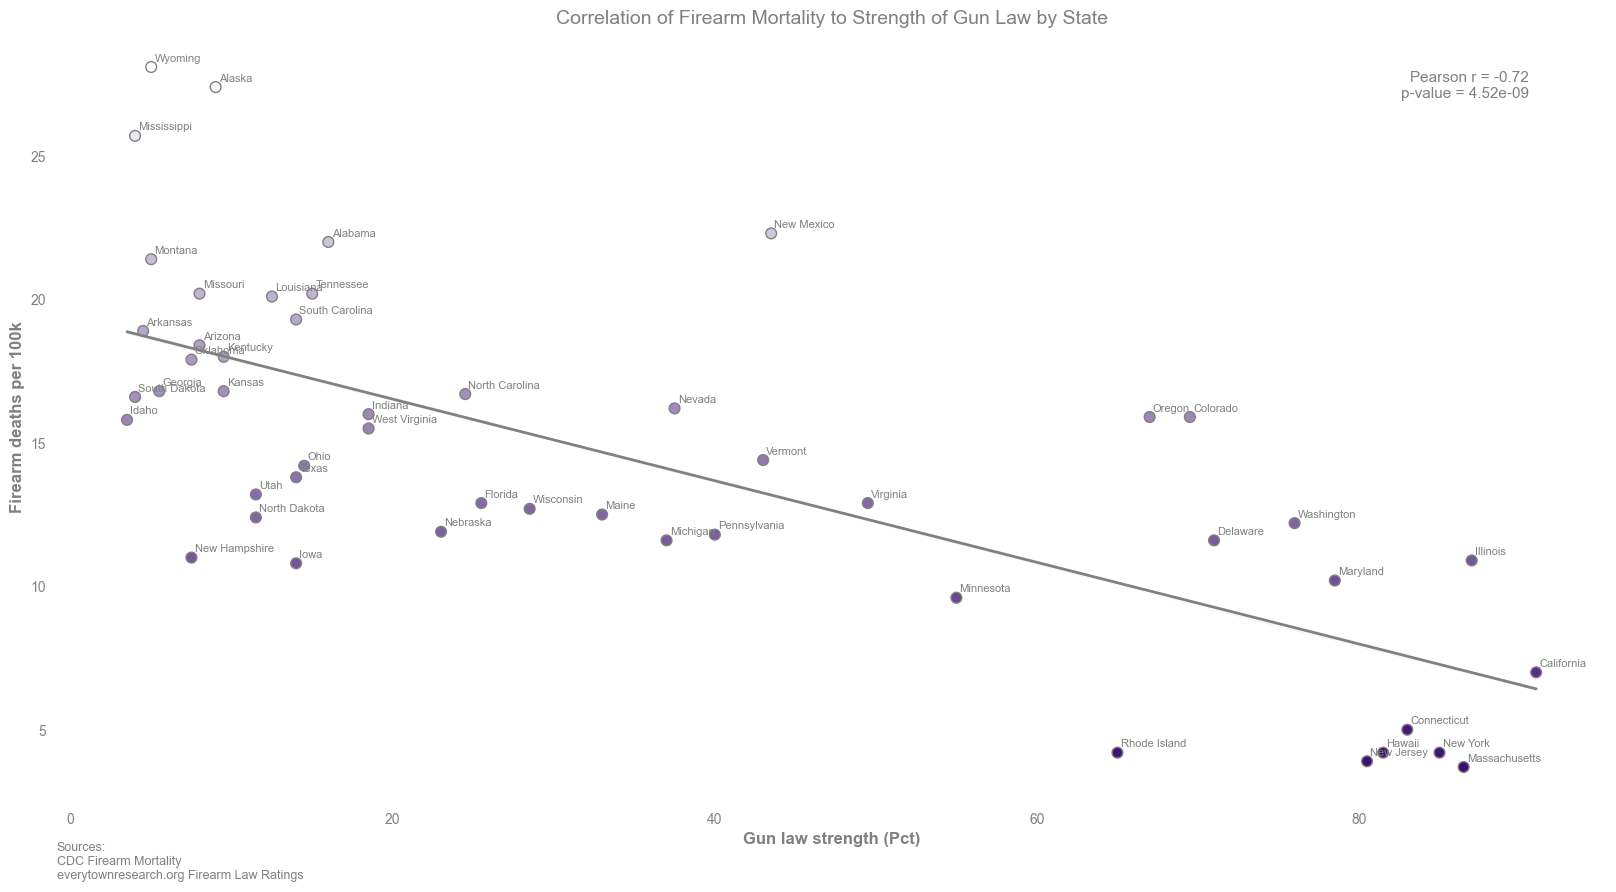

In [653]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20,10))

norm = plt.Normalize(df['rate_FA_Deaths'].min(), df['rate_FA_Deaths'].max())
colors = cmap(norm(df['rate_FA_Deaths']))

ax.scatter(
    df['Gun Law Strength'],
    df['rate_FA_Deaths'],
    c=colors,
    s=60,
    edgecolor = 'gray'
)

sns.regplot(
    x = 'Gun Law Strength',
    y = 'rate_FA_Deaths',
    data = df,
    ci = 0.95,
    scatter = False,
    line_kws = {'color': 'gray', 'linewidth':2},
    ax = ax
)

for i, row in df.iterrows():
    ax.text(
        row['Gun Law Strength'] + 0.2,   # shift right
        row['rate_FA_Deaths'] + 0.2,     # shift up
        row['State'],
        fontsize=8,
        color='gray'
    )

ax.set_title('Correlation of Firearm Mortality to Strength of Gun Law by State', color='gray', fontsize=14)
ax.set_xlabel('Gun law strength (Pct)', fontweight='bold', color='gray', fontsize=12)
ax.set_ylabel('Firearm deaths per 100k', fontweight='bold', color='gray', fontsize=12)

ax.text(
    0.95, 0.95,
    f"Pearson r = {pearson_corr:.2f}\np-value = {p:.2e}",
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=11,
    color='gray'
)

ax.grid(False)
ax.tick_params(
    axis='both',
    which='both',
    length=4,          # small tick marks
    color='gray',
    labelcolor='gray'  # tick numbers gray
)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.annotate(
    'Sources:\n'
    'CDC Firearm Mortality\n'
    'everytownresearch.org Firearm Law Ratings',
    xy = (0, -0.1),
    xycoords = 'axes fraction',
    ha='left',
    fontsize=9,
    color='gray'
)

plt.show()

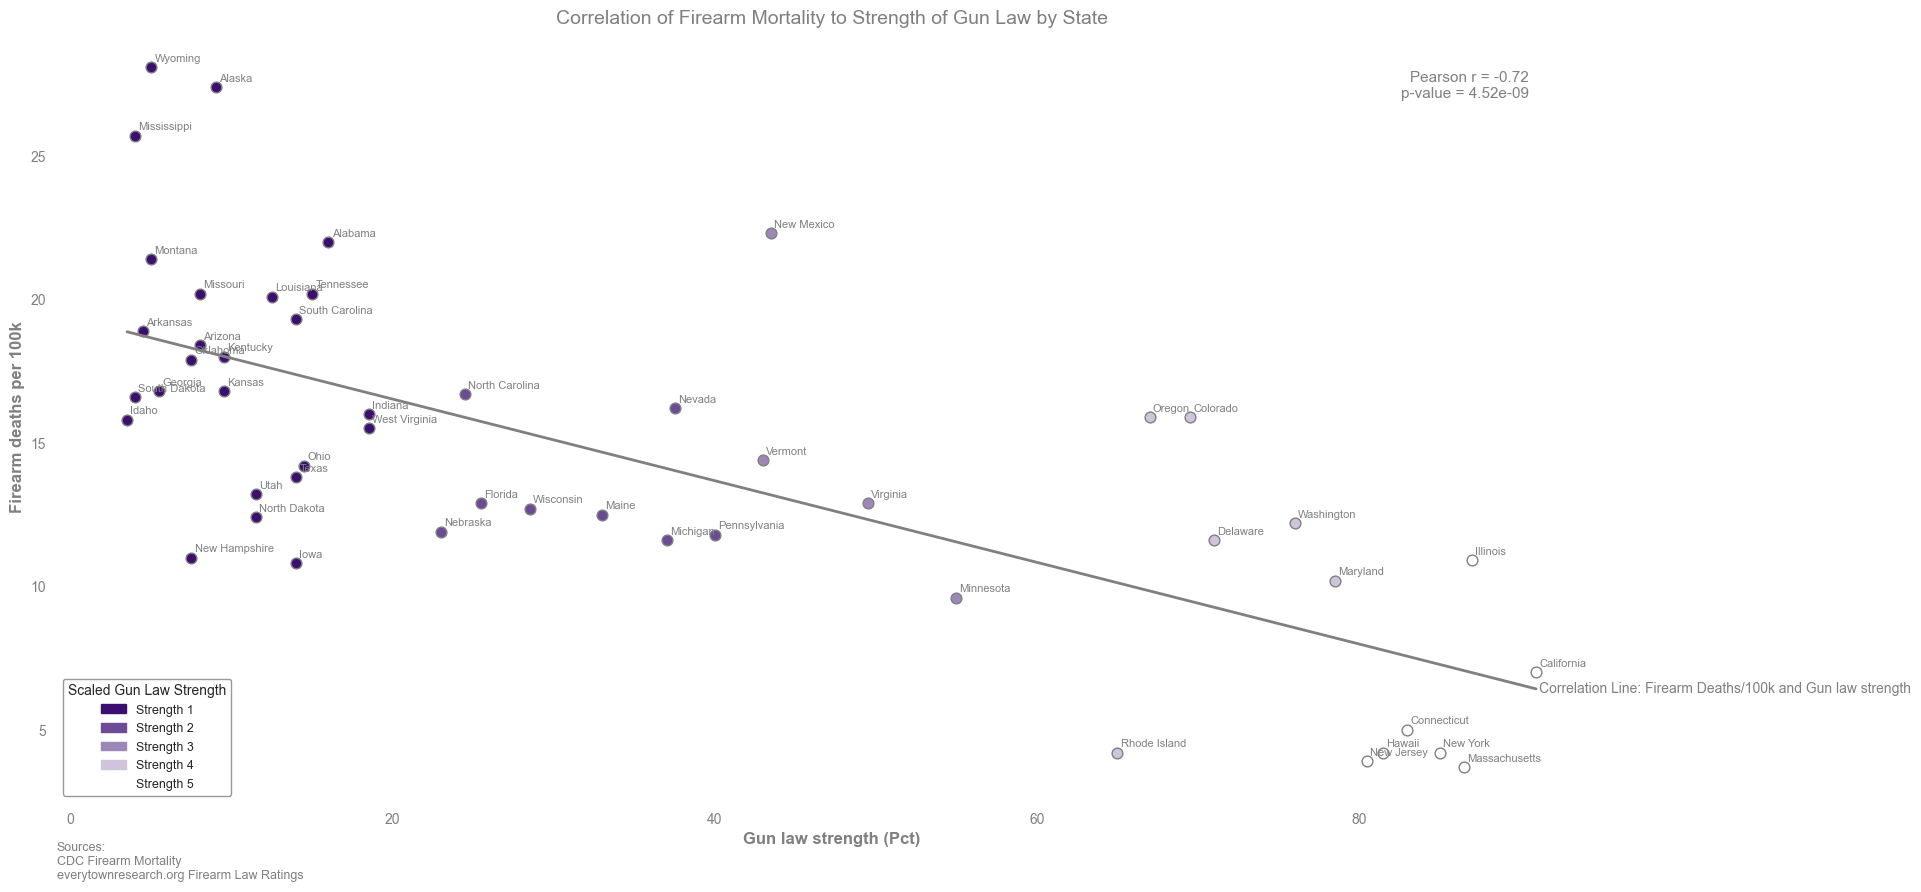

In [654]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(20,10))

# Define colors for each integer level (1-5)
levels = sorted(df['Scaled Gun Law Strength'].unique())
level_colors = {level: cmap((level-1)/4) for level in levels}  # normalize 0-1

# Scatter points colored by discrete Gun Law Strength
for level in levels:
    subset = df[df['Scaled Gun Law Strength'] == level]
    ax.scatter(
        subset['Gun Law Strength'],
        subset['rate_FA_Deaths'],
        c=[level_colors[level]],
        s=60,
        edgecolor='gray',
        label=f"Strength {level}"
    )

# Regression line
sns.regplot(
    x='Gun Law Strength',
    y='rate_FA_Deaths',
    data=df,
    ci=0.95,
    scatter=False,
    line_kws={'color': 'gray', 'linewidth':2},
    ax=ax
)

# Add label at the right end of the regression line
from numpy.polynomial.polynomial import polyfit
b, m = polyfit(df['Gun Law Strength'], df['rate_FA_Deaths'], 1)
x_max = df['Gun Law Strength'].max()
y_pred_max = m*x_max + b
ax.text(
    x_max + 0.2,
    y_pred_max,
    'Correlation Line: Firearm Deaths/100k and Gun law strength',
    color='gray',
    fontsize=10,
    va='center'
)

# State labels
for i, row in df.iterrows():
    ax.text(
        row['Gun Law Strength'] + 0.2,
        row['rate_FA_Deaths'] + 0.2,
        row['State'],
        fontsize=8,
        color='gray'
    )

# Titles and axis labels
ax.set_title('Correlation of Firearm Mortality to Strength of Gun Law by State', color='gray', fontsize=14)
ax.set_xlabel('Gun law strength (Pct)', fontweight='bold', color='gray', fontsize=12)
ax.set_ylabel('Firearm deaths per 100k', fontweight='bold', color='gray', fontsize=12)

# Pearson correlation text
ax.text(
    0.95, 0.95,
    f"Pearson r = {pearson_corr:.2f}\np-value = {p:.2e}",
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=11,
    color='gray'
)

# Legend as colored boxes
handles = [mpatches.Patch(color=level_colors[level], label=f"Strength {level}") for level in levels]
ax.legend(handles=handles, title='Scaled Gun Law Strength', frameon=True, edgecolor='gray', title_fontsize=10, fontsize=9)

# Grid, ticks, spines
ax.grid(False)
ax.tick_params(
    axis='both',
    which='both',
    length=4,
    color='gray',
    labelcolor='gray'
)
for spine in ax.spines.values():
    spine.set_visible(False)

# Source annotation
ax.annotate(
    'Sources:\nCDC Firearm Mortality\neverytownresearch.org Firearm Law Ratings',
    xy=(0, -0.1),
    xycoords='axes fraction',
    ha='left',
    fontsize=9,
    color='gray'
)

plt.show()

,FID,OBJECTID,NAME,STATE_ABBR,STATE_FIPS,ORDER_ADM,MONTH_ADM,DAY_ADM,YEAR_ADM,TYPE,...,Shape__Are,Shape__Len,geometry,State,Gun Law Strength,Scaled Gun Law Strength,name,rate_FA_Deaths,count_sup_FA_Deaths,Scaled FA Death
0,31,35,California,CA,06,31,September,9,1850,Land,...,41.613094,55.323399,"MULTIPOLYGON (((-1598326.932 -1213995.445, -15...",California,91.0,5,California,7.0,2735.0,7
1,5,5,Illinois,IL,17,21,December,3,1818,Land,...,15.408477,21.660211,"POLYGON ((781859.398 -231432.024, 782732.173 -...",Illinois,87.0,5,Illinois,10.9,1364.0,10
2,36,40,Massachusetts,MA,25,6,February,6,1788,Land,...,2.292561,23.274490,"MULTIPOLYGON (((2378108.756 13651.148, 2377937...",Massachusetts,86.5,5,Massachusetts,3.7,262.0,3
3,40,44,New York,NY,36,11,July,26,1788,Land,...,13.909031,42.221029,"MULTIPOLYGON (((2164948.709 -140966.9, 2165200...",New York,85.0,5,New York,4.2,830.0,4
4,32,36,Connecticut,CT,09,5,January,9,1788,Land,...,1.391289,7.986314,"MULTIPOLYGON (((2182116.638 -81334.636, 218207...",Connecticut,83.0,5,Connecticut,5.0,180.0,5
5,47,53,Hawaii,HI,15,50,August,21,1959,Land,...,1.439866,14.685215,"MULTIPOLYGON (((-5500094.564 -902713.613, -550...",Hawaii,81.5,5,Hawaii,4.2,60.0,4
6,39,43,New Jersey,NJ,34,3,December,18,1787,Land,...,2.072956,17.481320,"MULTIPOLYGON (((2147895.437 -301282.045, 21478...",New Jersey,80.5,5,New Jersey,3.9,360.0,3
7,37,41,Maryland,MD,24,7,April,28,1788,Land,...,2.664001,50.892779,"MULTIPOLYGON (((2021061.923 -322945.875, 20209...",Maryland,78.5,4,Maryland,10.2,631.0,10
8,52,59,Washington,WA,53,42,November,11,1889,Land,...,20.843773,58.093615,"MULTIPOLYGON (((-1766294.241 389004.697, -1766...",Washington,76.0,4,Washington,12.2,955.0,12
9,34,38,Delaware,DE,10,1,December,7,1787,Land,...,0.533126,5.468970,"MULTIPOLYGON (((2063417.154 -303087.343, 20632...",Delaware,71.0,4,Delaware,11.6,120.0,11


In [677]:
avg_df = df.groupby('Scaled Gun Law Strength').mean(numeric_only = True)

<Axes: xlabel='Scaled Gun Law Strength', ylabel='rate_FA_Deaths'>

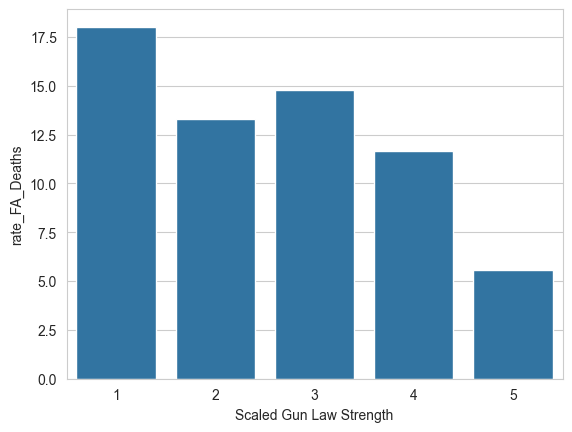

In [678]:
sns.barplot(avg_df, x = 'Scaled Gun Law Strength', y = 'rate_FA_Deaths',)